# 06-1 Log Size Feature Experiment

Objective: quickly test whether adding log-transformed size features improves the final XGBoost model, especially for high-price and large-home segments.

This is an experimental notebook only. It does not modify the main Week 7 or Week 8 notebooks.

Experiment design:
- Keep the current final XGBoost setup from `05_advanced_models.ipynb`.
- Feature set: `Base + Structural Derived + UnifiedSchoolDistrict`.
- Target transform: `log1p(ClosePrice)`.
- Hyperparameters: `max_depth=9`, `learning_rate=0.10`, `n_estimators=1200`.
- Compare two feature configurations:
  - `Current`
  - `Current + log size features`
- Evaluate on:
  - May 2026 validation fold
  - June 2026 final test month

Decision rule:
- Keep the log size features only if they improve overall metrics or high-price / large-home metrics without materially hurting R² or RMSE.


## 0. Setup


In [20]:
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "idx-california-price-prediction",
]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / "data" / "processed").exists() and (root / "notebooks").exists()
)
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
ENGINEERED_DATA_DIR = PROCESSED_DATA_DIR / "week6_feature_engineering"
ENGINEERED_SPLIT_DIR = ENGINEERED_DATA_DIR / "splits"
SPLIT_PLAN_CSV = PROCESSED_DATA_DIR / "crmls_week3_split_plan.csv"

ENGINEERED_CSV = ENGINEERED_DATA_DIR / "crmls_week6_engineered.csv"
FINAL_TRAIN_CSV = ENGINEERED_SPLIT_DIR / "final_train_fixed_window_engineered.csv"
TEST_CSV = ENGINEERED_SPLIT_DIR / "test_latest_month_engineered.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "log_size_feature_experiment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = "ClosePrice"
VALIDATION_MONTH = "2026-05"
TARGET_TRANSFORM = "log1p"
BEST_XGB_PARAMS = {
    "max_depth": 9,
    "learning_rate": 0.10,
    "n_estimators": 1200,
}

print(f"Project root: {PROJECT_ROOT}")
print(f"XGBoost version: {xgb.__version__}")
print(f"Output directory: {OUTPUT_DIR}")


Project root: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction
XGBoost version: 3.3.0
Output directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/log_size_feature_experiment


## 1. Load Data


In [21]:
CATEGORICAL_DTYPE_COLS = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "HighSchoolDistrict",
    "UnifiedSchoolDistrict",
]


def normalize_categorical_dtypes(df):
    for col in CATEGORICAL_DTYPE_COLS:
        if col in df.columns:
            df[col] = df[col].astype("string").fillna("__missing__")
    return df


def load_split_file(path):
    df = normalize_categorical_dtypes(pd.read_csv(path, low_memory=False))
    if "CloseDate" in df.columns:
        df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
    if "close_month" in df.columns:
        df["close_month"] = pd.PeriodIndex(df["close_month"], freq="M")
    return df


def add_log_size_features(df):
    result = df.copy()
    living_area = pd.to_numeric(result.get("LivingArea"), errors="coerce")
    lot_size = pd.to_numeric(result.get("LotSizeSquareFeet"), errors="coerce")
    result["LogLivingArea"] = np.where(living_area.gt(0), np.log1p(living_area), np.nan)
    result["LogLotSizeSquareFeet"] = np.where(lot_size.gt(0), np.log1p(lot_size), np.nan)
    return result


split_plan = pd.read_csv(SPLIT_PLAN_CSV, dtype={"split_type": "string", "eval_month": "string"})
historical_plan = split_plan[split_plan["split_type"].eq("historical_eval")].copy().sort_values("eval_month")
validation_plan = historical_plan[historical_plan["eval_month"].eq(VALIDATION_MONTH)].iloc[0]
final_plan = split_plan[split_plan["split_type"].eq("final_test")].iloc[0]

engineered_df = add_log_size_features(load_split_file(ENGINEERED_CSV))
final_train_raw = add_log_size_features(load_split_file(FINAL_TRAIN_CSV))
final_test_raw = add_log_size_features(load_split_file(TEST_CSV))

print(f"Engineered data shape: {engineered_df.shape}")
print(f"Final train shape: {final_train_raw.shape}")
print(f"Final test shape: {final_test_raw.shape}")
print(f"Validation fold: {validation_plan['train_month_start']} through {validation_plan['train_month_end']} -> {validation_plan['eval_month']}")
print(f"Final test: {final_plan['train_month_start']} through {final_plan['train_month_end']} -> {final_plan['eval_month']}")


Engineered data shape: (333060, 86)
Final train shape: (130114, 85)
Final test shape: (12858, 85)
Validation fold: 2025-05 through 2026-04 -> 2026-05
Final test: 2025-06 through 2026-05 -> 2026-06


## 2. Feature Configurations

The `Current` configuration mirrors the selected XGBoost feature set in `05_advanced_models.ipynb`. The experimental configuration adds only `LogLivingArea` and `LogLotSizeSquareFeet`.


In [22]:
LOCATION_QUALITY_FLAG_COLS = [
    "Latitude_missing",
    "Longitude_missing",
    "invalid_coordinates_flag",
    "PostalCode_format_issue_flag",
]

base_numeric_cols = [
    "LivingArea",
    "LotSizeSquareFeet",
    "Latitude",
    "Longitude",
    "AssociationFee",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
    "Flooring_material_count",
]
structural_model_numeric_cols = [
    "PropertyAgeYears",
    "BedBathRatio",
    "LivingAreaPerBedroom",
    "LogLotToLivingAreaRatio",
]
log_size_numeric_cols = [
    "LogLivingArea",
    "LogLotSizeSquareFeet",
]
base_structural_numeric_cols = base_numeric_cols + structural_model_numeric_cols

base_boolean_cols = [
    "ViewYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
    "Flooring_Carpet",
    "Flooring_Tile",
    "Flooring_Wood",
    "Flooring_Laminate",
    "Flooring_Vinyl",
    "Flooring_Stone",
    "Flooring_Concrete",
    "Flooring_Bamboo",
    "Flooring_Brick",
    "Flooring_SeeRemarks",
    "Flooring_multiple_materials_flag",
]
base_categorical_cols = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "HighSchoolDistrict",
    "UnifiedSchoolDistrict",
]
base_flag_cols = [
    col for col in engineered_df.columns
    if (col.endswith("_missing") or col == "invalid_coordinates_flag")
    and col not in LOCATION_QUALITY_FLAG_COLS
] + ["HasGarage"]


def available(columns, df):
    return [col for col in columns if col in df.columns]


FEATURE_CONFIGS = {
    "Current": {
        "numeric": base_structural_numeric_cols,
        "categorical": base_categorical_cols,
        "boolean": base_boolean_cols,
        "flag": base_flag_cols,
    },
    "Current + log size features": {
        "numeric": base_structural_numeric_cols + log_size_numeric_cols,
        "categorical": base_categorical_cols,
        "boolean": base_boolean_cols,
        "flag": base_flag_cols,
    },
}

feature_summary = []
for name, config in FEATURE_CONFIGS.items():
    numeric = available(config["numeric"], engineered_df)
    categorical = available(config["categorical"], engineered_df)
    boolean = available(config["boolean"], engineered_df)
    flag = available(config["flag"], engineered_df)
    feature_summary.append({
        "experiment": name,
        "numeric_features": len(numeric),
        "categorical_features": len(categorical),
        "boolean_features": len(boolean),
        "flag_features": len(flag),
        "total_raw_features": len(list(dict.fromkeys(numeric + categorical + boolean + flag))),
    })

feature_summary_df = pd.DataFrame(feature_summary)
display(feature_summary_df)


,experiment,numeric_features,categorical_features,boolean_features,flag_features,total_raw_features
0,Current,15,7,16,16,54
1,Current + log size features,17,7,16,16,56


## 3. Pipeline and Evaluation Helpers


In [23]:
HIGH_CARDINALITY_CATEGORICAL_COLS = ["City", "PostalCode", "MLSAreaMajor"]
HIGH_CARDINALITY_MIN_FREQUENCY = 20


def make_regular_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_high_cardinality_encoder(min_frequency=HIGH_CARDINALITY_MIN_FREQUENCY):
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse=True,
        )


def split_categorical_features(categorical_features):
    high_cardinality_features = [col for col in categorical_features if col in HIGH_CARDINALITY_CATEGORICAL_COLS]
    regular_categorical_features = [col for col in categorical_features if col not in HIGH_CARDINALITY_CATEGORICAL_COLS]
    return high_cardinality_features, regular_categorical_features


def build_preprocessing_pipeline(numeric_features, categorical_features, boolean_features, flag_features):
    high_cardinality_features, regular_categorical_features = split_categorical_features(categorical_features)
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), numeric_features),
            ("high_cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                ("onehot", make_high_cardinality_encoder()),
            ]), high_cardinality_features),
            ("regular_cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                ("onehot", make_regular_onehot_encoder()),
            ]), regular_categorical_features),
            ("bool", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))]), boolean_features),
            ("flag", Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value=0))]), flag_features),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True,
    )


def build_xgboost_pipeline(numeric_features, categorical_features, boolean_features, flag_features):
    preprocess = build_preprocessing_pipeline(numeric_features, categorical_features, boolean_features, flag_features)
    model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **BEST_XGB_PARAMS,
    )
    return Pipeline(steps=[("preprocess", preprocess), ("model", model)])


def rows_for_plan(plan_row, source_df):
    train_start = pd.Period(str(plan_row["train_month_start"]), freq="M")
    train_end = pd.Period(str(plan_row["train_month_end"]), freq="M")
    eval_month = pd.Period(str(plan_row["eval_month"]), freq="M")
    train_df = source_df[source_df["close_month"].between(train_start, train_end)].copy()
    eval_df = source_df[source_df["close_month"].eq(eval_month)].copy()
    return train_df, eval_df


def compute_price_per_sqft(df, target_col=TARGET, living_area_col="LivingArea"):
    close_price = pd.to_numeric(df[target_col], errors="coerce")
    living_area = pd.to_numeric(df[living_area_col], errors="coerce")
    return close_price.where(close_price.gt(0)) / living_area.where(living_area.gt(0))


def apply_train_price_bounds(train_df, eval_df, lower_q=0.005, upper_q=0.995, ppsf_lower_q=0.01, ppsf_upper_q=0.99):
    lower_bound = train_df[TARGET].quantile(lower_q)
    upper_bound = train_df[TARGET].quantile(upper_q)
    train_ppsf = compute_price_per_sqft(train_df)
    eval_ppsf = compute_price_per_sqft(eval_df)
    ppsf_lower_bound = train_ppsf.quantile(ppsf_lower_q)
    ppsf_upper_bound = train_ppsf.quantile(ppsf_upper_q)

    train_price_mask = train_df[TARGET].between(lower_bound, upper_bound)
    eval_price_mask = eval_df[TARGET].between(lower_bound, upper_bound)
    train_ppsf_mask = train_ppsf.isna() | train_ppsf.between(ppsf_lower_bound, ppsf_upper_bound)
    eval_ppsf_mask = eval_ppsf.isna() | eval_ppsf.between(ppsf_lower_bound, ppsf_upper_bound)
    train_mask = train_price_mask & train_ppsf_mask
    eval_mask = eval_price_mask & eval_ppsf_mask

    return train_df.loc[train_mask].copy(), eval_df.loc[eval_mask].copy(), {
        "price_lower_bound": lower_bound,
        "price_upper_bound": upper_bound,
        "price_per_sqft_lower_bound": ppsf_lower_bound,
        "price_per_sqft_upper_bound": ppsf_upper_bound,
        "train_rows_before_filter": len(train_df),
        "train_rows_after_filter": int(train_mask.sum()),
        "eval_rows_before_filter": len(eval_df),
        "eval_rows_after_filter": int(eval_mask.sum()),
    }


def transform_target(y):
    return np.log1p(y)


def inverse_target(predictions):
    return np.clip(np.expm1(predictions), 0, None)


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    ape = ((y_true - y_pred).abs() / y_true).replace([np.inf, -np.inf], np.nan) * 100
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": ape.mean(),
        "mdape": ape.median(),
    }


def segment_metrics(eval_df, predictions):
    detail = eval_df[["ListingKey", TARGET, "LivingArea"]].copy()
    detail["predicted_ClosePrice"] = predictions
    detail["absolute_error"] = (detail[TARGET] - detail["predicted_ClosePrice"]).abs()
    detail["absolute_percentage_error"] = detail["absolute_error"] / detail[TARGET] * 100
    detail["ClosePrice_quintile"] = pd.qcut(
        detail[TARGET],
        q=5,
        labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"],
        duplicates="drop",
    )
    detail["living_area_segment"] = np.where(pd.to_numeric(detail["LivingArea"], errors="coerce").gt(5000), ">5,000 sqft", "<=5,000 sqft")

    rows = []
    for segment_type, group_col in [
        ("ClosePrice_quintile", "ClosePrice_quintile"),
        ("living_area_segment", "living_area_segment"),
    ]:
        for value, group in detail.groupby(group_col, observed=True):
            metrics = regression_metrics(group[TARGET], group["predicted_ClosePrice"])
            rows.append({
                "segment_type": segment_type,
                "segment_value": str(value),
                "count": len(group),
                "median_actual_price": group[TARGET].median(),
                **metrics,
            })
    return pd.DataFrame(rows), detail


## 4. Run Experiment

This cell fits two XGBoost models per evaluation split. It may take a few minutes because it uses the same final hyperparameters as the main model.


In [24]:
def evaluate_config(eval_name, train_raw, eval_raw, experiment_name, feature_config):
    train_df, eval_df, bound_info = apply_train_price_bounds(train_raw, eval_raw)
    numeric_features = available(feature_config["numeric"], train_df)
    categorical_features = available(feature_config["categorical"], train_df)
    boolean_features = available(feature_config["boolean"], train_df)
    flag_features = available(feature_config["flag"], train_df)
    feature_cols = list(dict.fromkeys(numeric_features + categorical_features + boolean_features + flag_features))

    model = build_xgboost_pipeline(numeric_features, categorical_features, boolean_features, flag_features)
    start_time = time.perf_counter()
    model.fit(train_df[feature_cols], transform_target(train_df[TARGET]))
    fit_seconds = time.perf_counter() - start_time

    train_predictions = inverse_target(model.predict(train_df[feature_cols]))
    eval_predictions = inverse_target(model.predict(eval_df[feature_cols]))
    train_metrics = regression_metrics(train_df[TARGET], train_predictions)
    eval_metrics = regression_metrics(eval_df[TARGET], eval_predictions)
    segment_summary, detail = segment_metrics(eval_df, eval_predictions)

    result = {
        "eval_name": eval_name,
        "experiment": experiment_name,
        "target_transform": TARGET_TRANSFORM,
        **BEST_XGB_PARAMS,
        **bound_info,
        "n_raw_features": len(feature_cols),
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "eval_r2": eval_metrics["r2"],
        "eval_mae": eval_metrics["mae"],
        "eval_rmse": eval_metrics["rmse"],
        "eval_mape": eval_metrics["mape"],
        "eval_mdape": eval_metrics["mdape"],
        "train_eval_r2_gap": train_metrics["r2"] - eval_metrics["r2"],
    }
    segment_summary.insert(0, "experiment", experiment_name)
    segment_summary.insert(0, "eval_name", eval_name)
    detail.insert(0, "experiment", experiment_name)
    detail.insert(0, "eval_name", eval_name)
    return result, segment_summary, detail


validation_train_raw, validation_raw = rows_for_plan(validation_plan, engineered_df)
evaluation_splits = {
    "validation_2026-05": (validation_train_raw, validation_raw),
    "final_test_2026-06": (final_train_raw, final_test_raw),
}

result_rows = []
segment_frames = []
detail_frames = []

for eval_name, (train_raw, eval_raw) in evaluation_splits.items():
    for experiment_name, feature_config in FEATURE_CONFIGS.items():
        print(f"Running {eval_name}: {experiment_name}")
        result, segment_summary, detail = evaluate_config(eval_name, train_raw, eval_raw, experiment_name, feature_config)
        result_rows.append(result)
        segment_frames.append(segment_summary)
        detail_frames.append(detail)

experiment_results_df = pd.DataFrame(result_rows).sort_values(["eval_name", "eval_mdape", "eval_r2"], ascending=[True, True, False])
segment_results_df = pd.concat(segment_frames, ignore_index=True)
prediction_detail_df = pd.concat(detail_frames, ignore_index=True)

experiment_results_df.to_csv(OUTPUT_DIR / "log_size_experiment_results.csv", index=False)
segment_results_df.to_csv(OUTPUT_DIR / "log_size_experiment_segment_results.csv", index=False)
prediction_detail_df.to_csv(OUTPUT_DIR / "log_size_experiment_predictions.csv", index=False)

display(experiment_results_df.round(4))


Running validation_2026-05: Current
Running validation_2026-05: Current + log size features
Running final_test_2026-06: Current
Running final_test_2026-06: Current + log size features


,eval_name,experiment,target_transform,max_depth,learning_rate,n_estimators,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_filter,train_rows_after_filter,eval_rows_before_filter,eval_rows_after_filter,n_raw_features,fit_seconds,train_r2,train_mae,eval_r2,eval_mae,eval_rmse,eval_mape,eval_mdape,train_eval_r2_gap
2,final_test_2026-06,Current,log1p,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,54,14.1310,0.9719,86159.8675,0.9087,148075.0993,289276.1337,10.8434,7.6545,0.0633
3,final_test_2026-06,Current + log size features,log1p,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,56,14.1717,0.9719,86159.8675,0.9087,148075.0993,289276.1337,10.8434,7.6545,0.0633
0,validation_2026-05,Current,log1p,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,54,14.3605,0.9732,85145.1720,0.9019,150469.7986,295405.5042,10.9460,7.7426,0.0713
1,validation_2026-05,Current + log size features,log1p,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,56,15.4916,0.9732,85145.1720,0.9019,150469.7986,295405.5042,10.9460,7.7426,0.0713


## 5. Segment Comparison


Segment comparison: ClosePrice_quintile


,eval_name,experiment,segment_type,segment_value,count,median_actual_price,r2,mae,rmse,mape,mdape
14,final_test_2026-06,Current,ClosePrice_quintile,Q1 lowest,2535,455000.0,0.3300,47141.8052,74289.9183,11.2374,6.8499
21,final_test_2026-06,Current + log size features,ClosePrice_quintile,Q1 lowest,2535,455000.0,0.3300,47141.8052,74289.9183,11.2374,6.8499
15,final_test_2026-06,Current,ClosePrice_quintile,Q2,2482,700000.0,-0.7531,57459.3095,85089.8825,8.2895,5.6768
22,final_test_2026-06,Current + log size features,ClosePrice_quintile,Q2,2482,700000.0,-0.7531,57459.3095,85089.8825,8.2895,5.6768
16,final_test_2026-06,Current,ClosePrice_quintile,Q3,2551,925000.0,-1.4748,90056.8161,133215.1675,9.5263,6.8794
23,final_test_2026-06,Current + log size features,ClosePrice_quintile,Q3,2551,925000.0,-1.4748,90056.8161,133215.1675,9.5263,6.8794
17,final_test_2026-06,Current,ClosePrice_quintile,Q4,2463,1326000.0,-0.9010,149221.1407,208958.2213,11.0648,8.7205
24,final_test_2026-06,Current + log size features,ClosePrice_quintile,Q4,2463,1326000.0,-0.9010,149221.1407,208958.2213,11.0648,8.7205
18,final_test_2026-06,Current,ClosePrice_quintile,Q5 highest,2507,2289210.0,0.7565,397758.4782,587196.6244,14.0961,11.5751
25,final_test_2026-06,Current + log size features,ClosePrice_quintile,Q5 highest,2507,2289210.0,0.7565,397758.4782,587196.6244,14.0961,11.5751


Segment comparison: living_area_segment


,eval_name,experiment,segment_type,segment_value,count,median_actual_price,r2,mae,rmse,mape,mdape
19,final_test_2026-06,Current,living_area_segment,"<=5,000 sqft",12365,914000.0,0.9041,139082.8035,2.620664e+05,10.7219,7.5929
26,final_test_2026-06,Current + log size features,living_area_segment,"<=5,000 sqft",12365,914000.0,0.9041,139082.8035,2.620664e+05,10.7219,7.5929
20,final_test_2026-06,Current,living_area_segment,">5,000 sqft",173,4300000.0,0.7160,790790.3439,1.075139e+06,19.5273,13.9130
27,final_test_2026-06,Current + log size features,living_area_segment,">5,000 sqft",173,4300000.0,0.7160,790790.3439,1.075139e+06,19.5273,13.9130


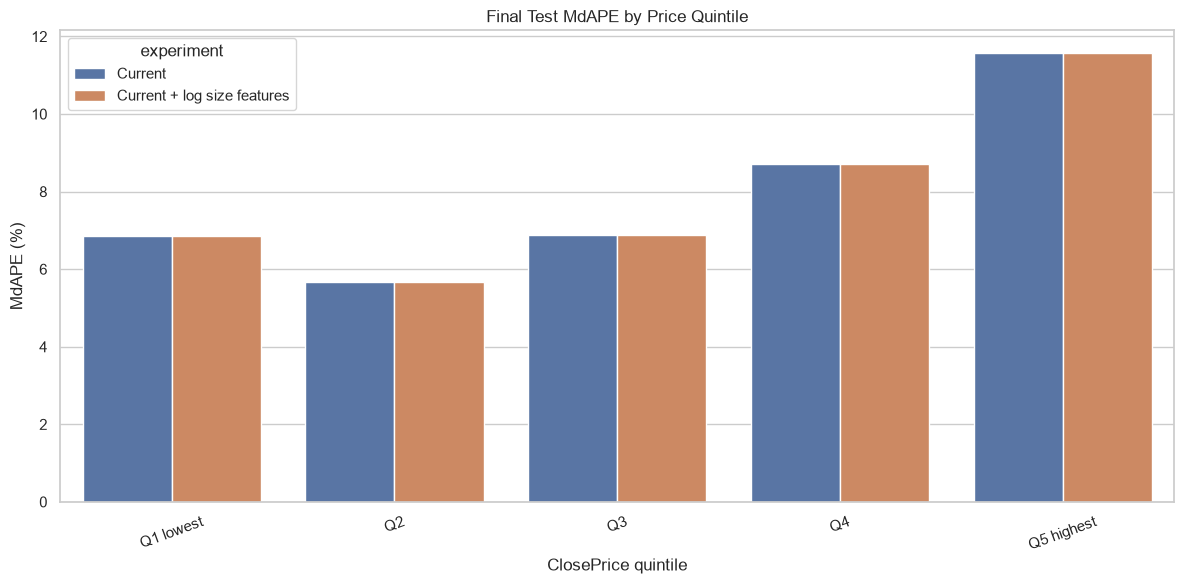

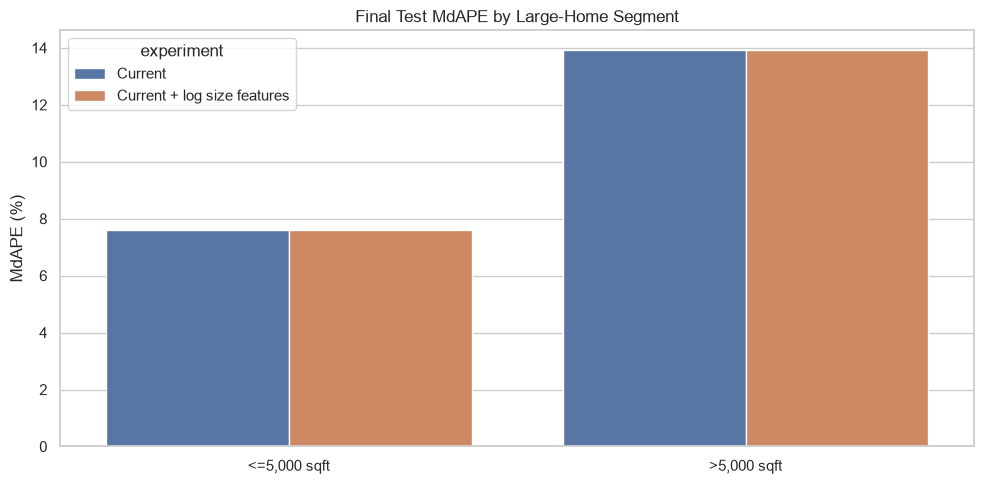

In [25]:
final_segment_comparison = segment_results_df[segment_results_df["eval_name"].eq("final_test_2026-06")].copy()

for segment_type in ["ClosePrice_quintile", "living_area_segment"]:
    print(f"Segment comparison: {segment_type}")
    display(
        final_segment_comparison[final_segment_comparison["segment_type"].eq(segment_type)]
        .sort_values(["segment_value", "experiment"])
        .round(4)
    )

plt.figure(figsize=(12, 6))
plot_df = final_segment_comparison[final_segment_comparison["segment_type"].eq("ClosePrice_quintile")].copy()
sns.barplot(data=plot_df, x="segment_value", y="mdape", hue="experiment")
plt.title("Final Test MdAPE by Price Quintile")
plt.xlabel("ClosePrice quintile")
plt.ylabel("MdAPE (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plot_df = final_segment_comparison[final_segment_comparison["segment_type"].eq("living_area_segment")].copy()
sns.barplot(data=plot_df, x="segment_value", y="mdape", hue="experiment")
plt.title("Final Test MdAPE by Large-Home Segment")
plt.xlabel("")
plt.ylabel("MdAPE (%)")
plt.tight_layout()
plt.show()


## 5.1 Log Size Experiment Summary Table


In [26]:
def q5_bias_label(mean_residual, tolerance=0):
    if pd.isna(mean_residual):
        return "unknown"
    if mean_residual > tolerance:
        return "under"
    if mean_residual < -tolerance:
        return "over"
    return "neutral"


def final_experiment_summary_table(results_df, detail_df, experiment_col="experiment"):
    final_results = results_df[results_df["eval_name"].eq("final_test_2026-06")].copy()
    final_detail = detail_df[detail_df["eval_name"].eq("final_test_2026-06")].copy()
    rows = []

    for experiment_name in final_results[experiment_col].drop_duplicates():
        result_row = final_results[final_results[experiment_col].eq(experiment_name)].iloc[0]
        experiment_detail = final_detail[final_detail[experiment_col].eq(experiment_name)].copy()
        q1_q4 = experiment_detail[
            experiment_detail["ClosePrice_quintile"].astype("string").isin(["Q1 lowest", "Q2", "Q3", "Q4"])
        ]
        q5 = experiment_detail[experiment_detail["ClosePrice_quintile"].astype("string").eq("Q5 highest")]
        q5_residual = q5[TARGET] - q5["predicted_ClosePrice"]

        rows.append({
            "Experiment": experiment_name,
            "Overall MdAPE": result_row["eval_mdape"],
            "Q1-Q4 MdAPE": q1_q4["absolute_percentage_error"].median(),
            "Q5 MdAPE": q5["absolute_percentage_error"].median(),
            "Q5 MAE": q5["absolute_error"].mean(),
            "Q5 Bias": q5_bias_label(q5_residual.mean()),
            "Q5 mean residual": q5_residual.mean(),
        })

    return pd.DataFrame(rows).sort_values("Overall MdAPE").reset_index(drop=True)


log_size_summary_table = final_experiment_summary_table(experiment_results_df, prediction_detail_df)
log_size_summary_table.to_csv(OUTPUT_DIR / "log_size_experiment_decision_summary.csv", index=False)
display(log_size_summary_table.round({
    "Overall MdAPE": 4,
    "Q1-Q4 MdAPE": 4,
    "Q5 MdAPE": 4,
    "Q5 MAE": 2,
    "Q5 mean residual": 2,
}))


,Experiment,Overall MdAPE,Q1-Q4 MdAPE,Q5 MdAPE,Q5 MAE,Q5 Bias,Q5 mean residual
0,Current,7.6545,6.9239,11.5751,397758.48,under,192315.92
1,Current + log size features,7.6545,6.9239,11.5751,397758.48,under,192315.92


## 6. Sample Weighting Experiment

Because `log1p(ClosePrice)` improves percentage-error metrics but can reduce the influence of luxury observations, test whether giving the top 20% of training prices a modestly higher weight reduces high-price underprediction.

This experiment keeps the current selected feature set and final XGBoost hyperparameters. It compares:
- `unweighted`
- `top20_weight_1.5`
- `top20_weight_2.0`

Decision rule:
- Prefer a weighted version only if Q5 / high-price MAE or MdAPE improves without materially hurting overall MdAPE, R², or RMSE.


In [27]:
SAMPLE_WEIGHT_CONFIGS = {
    "unweighted": None,
    "top20_weight_1.5": 1.5,
    "top20_weight_2.0": 2.0,
}


def make_top_price_sample_weight(y, top_quantile=0.80, top_weight=1.5):
    y = pd.Series(y).astype(float)
    weights = pd.Series(1.0, index=y.index)
    threshold = y.quantile(top_quantile)
    weights.loc[y.ge(threshold)] = top_weight
    return weights, threshold


def evaluate_weighted_config(eval_name, train_raw, eval_raw, experiment_name, feature_config, top_weight):
    train_df, eval_df, bound_info = apply_train_price_bounds(train_raw, eval_raw)
    numeric_features = available(feature_config["numeric"], train_df)
    categorical_features = available(feature_config["categorical"], train_df)
    boolean_features = available(feature_config["boolean"], train_df)
    flag_features = available(feature_config["flag"], train_df)
    feature_cols = list(dict.fromkeys(numeric_features + categorical_features + boolean_features + flag_features))

    model = build_xgboost_pipeline(numeric_features, categorical_features, boolean_features, flag_features)
    sample_weight = None
    top_price_threshold = np.nan
    if top_weight is not None:
        sample_weight, top_price_threshold = make_top_price_sample_weight(train_df[TARGET], top_weight=top_weight)

    start_time = time.perf_counter()
    if sample_weight is None:
        model.fit(train_df[feature_cols], transform_target(train_df[TARGET]))
    else:
        model.fit(
            train_df[feature_cols],
            transform_target(train_df[TARGET]),
            model__sample_weight=sample_weight,
        )
    fit_seconds = time.perf_counter() - start_time

    train_predictions = inverse_target(model.predict(train_df[feature_cols]))
    eval_predictions = inverse_target(model.predict(eval_df[feature_cols]))
    train_metrics = regression_metrics(train_df[TARGET], train_predictions)
    eval_metrics = regression_metrics(eval_df[TARGET], eval_predictions)
    segment_summary, detail = segment_metrics(eval_df, eval_predictions)

    q5_detail = detail[detail["ClosePrice_quintile"].astype("string").eq("Q5 highest")].copy()
    q5_metrics = regression_metrics(q5_detail[TARGET], q5_detail["predicted_ClosePrice"])
    q5_mean_residual = (q5_detail[TARGET] - q5_detail["predicted_ClosePrice"]).mean()

    result = {
        "eval_name": eval_name,
        "experiment": experiment_name,
        "target_transform": TARGET_TRANSFORM,
        "top_price_weight": 1.0 if top_weight is None else top_weight,
        "top_price_threshold": top_price_threshold,
        **BEST_XGB_PARAMS,
        **bound_info,
        "n_raw_features": len(feature_cols),
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "eval_r2": eval_metrics["r2"],
        "eval_mae": eval_metrics["mae"],
        "eval_rmse": eval_metrics["rmse"],
        "eval_mape": eval_metrics["mape"],
        "eval_mdape": eval_metrics["mdape"],
        "train_eval_r2_gap": train_metrics["r2"] - eval_metrics["r2"],
        "q5_mae": q5_metrics["mae"],
        "q5_mape": q5_metrics["mape"],
        "q5_mdape": q5_metrics["mdape"],
        "q5_mean_residual": q5_mean_residual,
    }
    segment_summary.insert(0, "experiment", experiment_name)
    segment_summary.insert(0, "eval_name", eval_name)
    detail.insert(0, "experiment", experiment_name)
    detail.insert(0, "eval_name", eval_name)
    return result, segment_summary, detail


weighted_result_rows = []
weighted_segment_frames = []
weighted_detail_frames = []
current_feature_config = FEATURE_CONFIGS["Current"]

for eval_name, (train_raw, eval_raw) in evaluation_splits.items():
    for experiment_name, top_weight in SAMPLE_WEIGHT_CONFIGS.items():
        print(f"Running sample weighting {eval_name}: {experiment_name}")
        result, segment_summary, detail = evaluate_weighted_config(
            eval_name,
            train_raw,
            eval_raw,
            experiment_name,
            current_feature_config,
            top_weight,
        )
        weighted_result_rows.append(result)
        weighted_segment_frames.append(segment_summary)
        weighted_detail_frames.append(detail)

weighted_results_df = pd.DataFrame(weighted_result_rows).sort_values(
    ["eval_name", "eval_mdape", "eval_r2"],
    ascending=[True, True, False],
)
weighted_segment_results_df = pd.concat(weighted_segment_frames, ignore_index=True)
weighted_prediction_detail_df = pd.concat(weighted_detail_frames, ignore_index=True)

weighted_results_df.to_csv(OUTPUT_DIR / "sample_weighting_experiment_results.csv", index=False)
weighted_segment_results_df.to_csv(OUTPUT_DIR / "sample_weighting_experiment_segment_results.csv", index=False)
weighted_prediction_detail_df.to_csv(OUTPUT_DIR / "sample_weighting_experiment_predictions.csv", index=False)

display(weighted_results_df.round(4))


Running sample weighting validation_2026-05: unweighted
Running sample weighting validation_2026-05: top20_weight_1.5
Running sample weighting validation_2026-05: top20_weight_2.0
Running sample weighting final_test_2026-06: unweighted
Running sample weighting final_test_2026-06: top20_weight_1.5
Running sample weighting final_test_2026-06: top20_weight_2.0


,eval_name,experiment,target_transform,top_price_weight,top_price_threshold,max_depth,learning_rate,n_estimators,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_filter,train_rows_after_filter,eval_rows_before_filter,eval_rows_after_filter,n_raw_features,fit_seconds,train_r2,train_mae,eval_r2,eval_mae,eval_rmse,eval_mape,eval_mdape,train_eval_r2_gap,q5_mae,q5_mape,q5_mdape,q5_mean_residual
3,final_test_2026-06,unweighted,log1p,1.0,NaN,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,54,14.9245,0.9719,86159.8675,0.9087,148075.0993,289276.1337,10.8434,7.6545,0.0633,397758.4782,14.0961,11.5751,192315.9172
4,final_test_2026-06,top20_weight_1.5,log1p,1.5,1575000.0,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,54,15.5327,0.9742,85232.6611,0.9096,148833.6134,287842.7580,10.9535,7.7512,0.0647,394973.8574,13.9713,11.2326,181036.7093
5,final_test_2026-06,top20_weight_2.0,log1p,2.0,1575000.0,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,54,14.2085,0.9755,84738.8113,0.9073,150648.2261,291357.2877,11.1298,7.7941,0.0681,393887.3498,13.8633,11.2416,180984.3483
0,validation_2026-05,unweighted,log1p,1.0,NaN,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,54,16.9856,0.9732,85145.1720,0.9019,150469.7986,295405.5042,10.9460,7.7426,0.0713,406106.2678,14.2805,11.6585,193408.0405
1,validation_2026-05,top20_weight_1.5,log1p,1.5,1575000.0,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,54,14.8158,0.9750,84138.9877,0.9012,151364.9238,296507.9216,11.0644,7.7812,0.0738,402244.5994,14.1379,11.3982,182132.2091
2,validation_2026-05,top20_weight_2.0,log1p,2.0,1575000.0,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,54,14.9030,0.9761,83943.1610,0.9028,151855.7321,294088.6925,11.2013,7.9485,0.0733,394526.2243,13.7617,11.0405,181344.1538


## 7. Sample Weighting Segment Comparison


Weighted segment comparison: ClosePrice_quintile


,eval_name,experiment,segment_type,segment_value,count,median_actual_price,r2,mae,rmse,mape,mdape
28,final_test_2026-06,top20_weight_1.5,ClosePrice_quintile,Q1 lowest,2535,455000.0,0.3542,47029.3338,72937.1687,11.2243,6.8806
35,final_test_2026-06,top20_weight_2.0,ClosePrice_quintile,Q1 lowest,2535,455000.0,0.2901,47489.2098,76469.2028,11.3256,6.6902
21,final_test_2026-06,unweighted,ClosePrice_quintile,Q1 lowest,2535,455000.0,0.3300,47141.8052,74289.9183,11.2374,6.8499
29,final_test_2026-06,top20_weight_1.5,ClosePrice_quintile,Q2,2482,700000.0,-0.7832,58197.0546,85817.2694,8.4026,5.6407
36,final_test_2026-06,top20_weight_2.0,ClosePrice_quintile,Q2,2482,700000.0,-0.8437,59263.5170,87260.7443,8.5489,5.9547
22,final_test_2026-06,unweighted,ClosePrice_quintile,Q2,2482,700000.0,-0.7531,57459.3095,85089.8825,8.2895,5.6768
30,final_test_2026-06,top20_weight_1.5,ClosePrice_quintile,Q3,2551,925000.0,-1.7121,93852.1612,139455.3798,9.9237,7.3607
37,final_test_2026-06,top20_weight_2.0,ClosePrice_quintile,Q3,2551,925000.0,-1.8756,96954.5133,143598.9250,10.2426,7.3715
23,final_test_2026-06,unweighted,ClosePrice_quintile,Q3,2551,925000.0,-1.4748,90056.8161,133215.1675,9.5263,6.8794
31,final_test_2026-06,top20_weight_1.5,ClosePrice_quintile,Q4,2463,1326000.0,-0.8896,151358.1286,208333.6749,11.2404,8.7470


Weighted segment comparison: living_area_segment


,eval_name,experiment,segment_type,segment_value,count,median_actual_price,r2,mae,rmse,mape,mdape
33,final_test_2026-06,top20_weight_1.5,living_area_segment,"<=5,000 sqft",12365,914000.0,0.9024,140390.7281,2.643810e+05,10.8471,7.7059
40,final_test_2026-06,top20_weight_2.0,living_area_segment,"<=5,000 sqft",12365,914000.0,0.9008,141880.2575,2.665443e+05,11.0184,7.7290
26,final_test_2026-06,unweighted,living_area_segment,"<=5,000 sqft",12365,914000.0,0.9041,139082.8035,2.620664e+05,10.7219,7.5929
34,final_test_2026-06,top20_weight_1.5,living_area_segment,">5,000 sqft",173,4300000.0,0.7521,752280.3046,1.004430e+06,18.5622,12.9942
41,final_test_2026-06,top20_weight_2.0,living_area_segment,">5,000 sqft",173,4300000.0,0.7361,777329.9155,1.036493e+06,19.0955,15.0134
27,final_test_2026-06,unweighted,living_area_segment,">5,000 sqft",173,4300000.0,0.7160,790790.3439,1.075139e+06,19.5273,13.9130


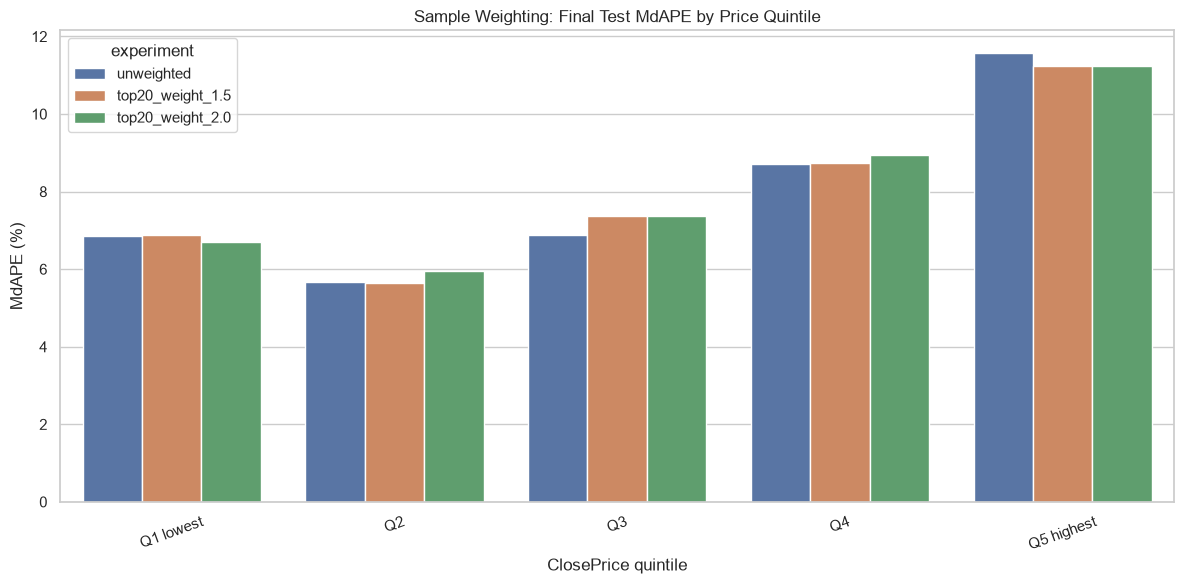

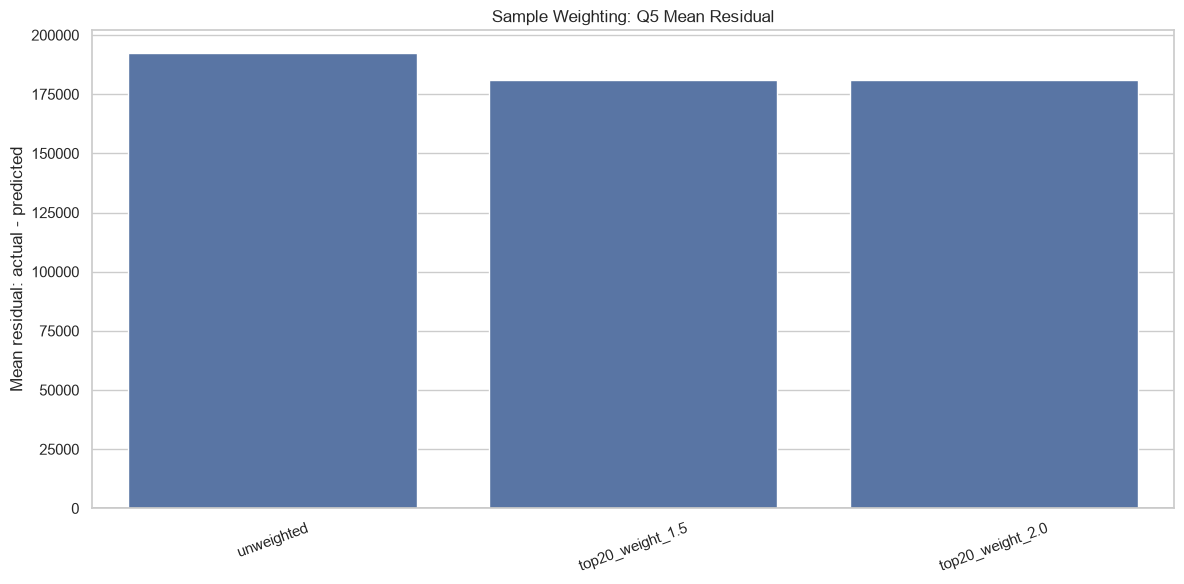

In [28]:
final_weighted_segment_comparison = weighted_segment_results_df[
    weighted_segment_results_df["eval_name"].eq("final_test_2026-06")
].copy()

for segment_type in ["ClosePrice_quintile", "living_area_segment"]:
    print(f"Weighted segment comparison: {segment_type}")
    display(
        final_weighted_segment_comparison[final_weighted_segment_comparison["segment_type"].eq(segment_type)]
        .sort_values(["segment_value", "experiment"])
        .round(4)
    )

plt.figure(figsize=(12, 6))
plot_df = final_weighted_segment_comparison[
    final_weighted_segment_comparison["segment_type"].eq("ClosePrice_quintile")
].copy()
sns.barplot(data=plot_df, x="segment_value", y="mdape", hue="experiment")
plt.title("Sample Weighting: Final Test MdAPE by Price Quintile")
plt.xlabel("ClosePrice quintile")
plt.ylabel("MdAPE (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plot_df = weighted_results_df[weighted_results_df["eval_name"].eq("final_test_2026-06")].copy()
sns.barplot(data=plot_df, x="experiment", y="q5_mean_residual")
plt.axhline(0, color="black", linewidth=1)
plt.title("Sample Weighting: Q5 Mean Residual")
plt.xlabel("")
plt.ylabel("Mean residual: actual - predicted")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 7.1 Sample Weighting Summary Table


In [29]:
sample_weighting_summary_table = final_experiment_summary_table(weighted_results_df, weighted_prediction_detail_df)
sample_weighting_summary_table.to_csv(OUTPUT_DIR / "sample_weighting_experiment_decision_summary.csv", index=False)
display(sample_weighting_summary_table.round({
    "Overall MdAPE": 4,
    "Q1-Q4 MdAPE": 4,
    "Q5 MdAPE": 4,
    "Q5 MAE": 2,
    "Q5 mean residual": 2,
}))


,Experiment,Overall MdAPE,Q1-Q4 MdAPE,Q5 MdAPE,Q5 MAE,Q5 Bias,Q5 mean residual
0,unweighted,7.6545,6.9239,11.5751,397758.48,under,192315.92
1,top20_weight_1.5,7.7512,7.0657,11.2326,394973.86,under,181036.71
2,top20_weight_2.0,7.7941,7.1478,11.2416,393887.35,under,180984.35


## 8. Leakage-Safe Local Price Feature Experiment

Test whether the local median / 90th-percentile price features from `04_model_comparison.ipynb` improve the current XGBoost setup.

This experiment compares:
- `Current log1p`
- `+ local price features`

The local features are generated inside each training fold only, so the validation/test month is not used to compute ZIP or school-district aggregates.


In [30]:
ZIP_LOCAL_AGGREGATE_NUMERIC_COLS = [
    "zip_median_ppsf_6m",
    "zip_90pct_price_12m",
    "zip_sales_count_6m",
    "local_sales_count_6m",
    "LivingArea_x_zip_median_ppsf_6m",
    "LivingArea_x_local_median_ppsf",
]
DISTRICT_LOCAL_AGGREGATE_NUMERIC_COLS = [
    "district_median_ppsf_12m",
    "district_90pct_price_12m",
    "district_sales_count_12m",
    "LivingArea_x_district_median_ppsf_12m",
]


def local_aggregate_numeric_features(categorical_features):
    features = list(ZIP_LOCAL_AGGREGATE_NUMERIC_COLS)
    if "UnifiedSchoolDistrict" in categorical_features:
        features += DISTRICT_LOCAL_AGGREGATE_NUMERIC_COLS
    return features


class LocalAggregateFeatureTransformer(BaseEstimator, TransformerMixin):
    """Create train-fold-only local price features without precomputing target aggregates globally."""

    def __init__(self, target_col="ClosePrice", date_col="CloseDate", zip_col="PostalCode", district_col="UnifiedSchoolDistrict", living_area_col="LivingArea", min_count=20):
        self.target_col = target_col
        self.date_col = date_col
        self.zip_col = zip_col
        self.district_col = district_col
        self.living_area_col = living_area_col
        self.min_count = min_count

    def fit(self, X, y=None):
        history = X.copy()
        if self.target_col in history.columns:
            # Prefer raw ClosePrice from X so local price aggregates stay on dollar scale
            # even when the downstream model target is log-transformed.
            y_series = pd.to_numeric(history[self.target_col], errors="coerce")
        elif y is not None:
            y_series = pd.Series(y, index=history.index).astype(float)
        else:
            raise ValueError("Local aggregate features require raw ClosePrice in X during fit.")

        history[self.target_col] = y_series
        history[self.date_col] = pd.to_datetime(history.get(self.date_col), errors="coerce")
        history[self.living_area_col] = pd.to_numeric(history.get(self.living_area_col), errors="coerce")
        history["_ppsf"] = np.where(
            history[self.target_col].gt(0) & history[self.living_area_col].gt(0),
            history[self.target_col] / history[self.living_area_col],
            np.nan,
        )

        max_date = history[self.date_col].max()
        if pd.isna(max_date):
            history_6m = history.copy()
            history_12m = history.copy()
        else:
            history_6m = history[history[self.date_col].ge(max_date - pd.DateOffset(months=6))].copy()
            history_12m = history[history[self.date_col].ge(max_date - pd.DateOffset(months=12))].copy()

        self.global_median_ppsf_ = history["_ppsf"].median()
        self.zip_median_ppsf_6m_ = self._build_group_map(history_6m, self.zip_col, "_ppsf", "median")
        self.zip_90pct_price_12m_ = self._build_group_map(history_12m, self.zip_col, self.target_col, "q90")
        self.zip_sales_count_6m_ = self._build_group_map(history_6m, self.zip_col, self.target_col, "count")
        self.district_median_ppsf_12m_ = self._build_group_map(history_12m, self.district_col, "_ppsf", "median")
        self.district_90pct_price_12m_ = self._build_group_map(history_12m, self.district_col, self.target_col, "q90")
        self.district_sales_count_12m_ = self._build_group_map(history_12m, self.district_col, self.target_col, "count")
        self.global_sales_count_6m_ = len(history_6m)
        return self

    def transform(self, X):
        X_out = X.copy()
        zip_values = X_out[self.zip_col].astype("string") if self.zip_col in X_out.columns else pd.Series(pd.NA, index=X_out.index)
        district_values = X_out[self.district_col].astype("string") if self.district_col in X_out.columns else pd.Series(pd.NA, index=X_out.index)
        living_area = pd.to_numeric(X_out.get(self.living_area_col), errors="coerce")

        zip_median_ppsf_6m = zip_values.map(self.zip_median_ppsf_6m_).astype(float)
        zip_90pct_price_12m = zip_values.map(self.zip_90pct_price_12m_).astype(float)
        zip_sales_count_6m = zip_values.map(self.zip_sales_count_6m_).astype(float)
        district_median_ppsf_12m = district_values.map(self.district_median_ppsf_12m_).astype(float)
        district_90pct_price_12m = district_values.map(self.district_90pct_price_12m_).astype(float)
        district_sales_count_12m = district_values.map(self.district_sales_count_12m_).astype(float)

        local_median_ppsf = zip_median_ppsf_6m.fillna(district_median_ppsf_12m).fillna(self.global_median_ppsf_)
        local_sales_count_6m = zip_sales_count_6m.fillna(self.global_sales_count_6m_)

        X_out["zip_median_ppsf_6m"] = zip_median_ppsf_6m
        X_out["zip_90pct_price_12m"] = zip_90pct_price_12m
        X_out["zip_sales_count_6m"] = zip_sales_count_6m
        X_out["district_median_ppsf_12m"] = district_median_ppsf_12m
        X_out["district_90pct_price_12m"] = district_90pct_price_12m
        X_out["district_sales_count_12m"] = district_sales_count_12m
        X_out["local_sales_count_6m"] = local_sales_count_6m
        X_out["LivingArea_x_zip_median_ppsf_6m"] = living_area * zip_median_ppsf_6m
        X_out["LivingArea_x_district_median_ppsf_12m"] = living_area * district_median_ppsf_12m
        X_out["LivingArea_x_local_median_ppsf"] = living_area * local_median_ppsf
        return X_out

    def _build_group_map(self, df, group_col, value_col, agg_name):
        if group_col not in df.columns:
            return pd.Series(dtype=float)
        grouped = df.dropna(subset=[group_col, value_col]).copy()
        grouped[group_col] = grouped[group_col].astype("string")
        group_sizes = grouped.groupby(group_col, observed=True)[value_col].size()
        valid_groups = group_sizes[group_sizes >= self.min_count].index
        grouped = grouped[grouped[group_col].isin(valid_groups)]
        if grouped.empty:
            return pd.Series(dtype=float)
        if agg_name == "median":
            return grouped.groupby(group_col, observed=True)[value_col].median()
        if agg_name == "q90":
            return grouped.groupby(group_col, observed=True)[value_col].quantile(0.90)
        if agg_name == "count":
            return grouped.groupby(group_col, observed=True)[value_col].size().astype(float)
        raise ValueError(f"Unsupported aggregate: {agg_name}")


def build_local_aggregate_xgboost_pipeline(numeric_features, categorical_features, boolean_features, flag_features):
    numeric_features = list(dict.fromkeys(list(numeric_features) + local_aggregate_numeric_features(categorical_features)))
    high_cardinality_features, regular_categorical_features = split_categorical_features(categorical_features)

    column_transformer = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), numeric_features),
            ("high_cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                ("onehot", make_high_cardinality_encoder()),
            ]), high_cardinality_features),
            ("regular_cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                ("onehot", make_regular_onehot_encoder()),
            ]), regular_categorical_features),
            ("bool", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))]), boolean_features),
            ("flag", Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value=0))]), flag_features),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True,
    )
    model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **BEST_XGB_PARAMS,
    )
    return Pipeline(steps=[
        ("local_aggregates", LocalAggregateFeatureTransformer(target_col=TARGET)),
        ("preprocess", column_transformer),
        ("model", model),
    ])


def evaluate_local_aggregate_config(eval_name, train_raw, eval_raw, experiment_name, feature_config, use_local_aggregates=False):
    train_df, eval_df, bound_info = apply_train_price_bounds(train_raw, eval_raw)
    numeric_features = available(feature_config["numeric"], train_df)
    categorical_features = available(feature_config["categorical"], train_df)
    boolean_features = available(feature_config["boolean"], train_df)
    flag_features = available(feature_config["flag"], train_df)
    local_source_features = available(["CloseDate", TARGET], train_df)
    feature_cols = list(dict.fromkeys(numeric_features + categorical_features + boolean_features + flag_features))

    if use_local_aggregates:
        model = build_local_aggregate_xgboost_pipeline(numeric_features, categorical_features, boolean_features, flag_features)
        feature_cols = list(dict.fromkeys(feature_cols + local_source_features))
    else:
        model = build_xgboost_pipeline(numeric_features, categorical_features, boolean_features, flag_features)

    start_time = time.perf_counter()
    model.fit(train_df[feature_cols], transform_target(train_df[TARGET]))
    fit_seconds = time.perf_counter() - start_time

    train_predictions = inverse_target(model.predict(train_df[feature_cols]))
    eval_predictions = inverse_target(model.predict(eval_df[feature_cols]))
    train_metrics = regression_metrics(train_df[TARGET], train_predictions)
    eval_metrics = regression_metrics(eval_df[TARGET], eval_predictions)
    segment_summary, detail = segment_metrics(eval_df, eval_predictions)

    q5_detail = detail[detail["ClosePrice_quintile"].astype("string").eq("Q5 highest")].copy()
    q5_metrics = regression_metrics(q5_detail[TARGET], q5_detail["predicted_ClosePrice"])
    q5_mean_residual = (q5_detail[TARGET] - q5_detail["predicted_ClosePrice"]).mean()

    result = {
        "eval_name": eval_name,
        "experiment": experiment_name,
        "target_transform": TARGET_TRANSFORM,
        "uses_local_aggregates": use_local_aggregates,
        **BEST_XGB_PARAMS,
        **bound_info,
        "n_raw_features": len(feature_cols),
        "n_model_numeric_features": len(numeric_features) + (len(local_aggregate_numeric_features(categorical_features)) if use_local_aggregates else 0),
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "eval_r2": eval_metrics["r2"],
        "eval_mae": eval_metrics["mae"],
        "eval_rmse": eval_metrics["rmse"],
        "eval_mape": eval_metrics["mape"],
        "eval_mdape": eval_metrics["mdape"],
        "train_eval_r2_gap": train_metrics["r2"] - eval_metrics["r2"],
        "q5_mae": q5_metrics["mae"],
        "q5_mape": q5_metrics["mape"],
        "q5_mdape": q5_metrics["mdape"],
        "q5_mean_residual": q5_mean_residual,
    }
    segment_summary.insert(0, "experiment", experiment_name)
    segment_summary.insert(0, "eval_name", eval_name)
    detail.insert(0, "experiment", experiment_name)
    detail.insert(0, "eval_name", eval_name)
    return result, segment_summary, detail


local_result_rows = []
local_segment_frames = []
local_detail_frames = []
local_experiment_configs = {
    "Current log1p": False,
    "+ local price features": True,
}

for eval_name, (train_raw, eval_raw) in evaluation_splits.items():
    for experiment_name, use_local_aggregates in local_experiment_configs.items():
        print(f"Running local aggregate {eval_name}: {experiment_name}")
        result, segment_summary, detail = evaluate_local_aggregate_config(
            eval_name,
            train_raw,
            eval_raw,
            experiment_name,
            FEATURE_CONFIGS["Current"],
            use_local_aggregates=use_local_aggregates,
        )
        local_result_rows.append(result)
        local_segment_frames.append(segment_summary)
        local_detail_frames.append(detail)

local_aggregate_results_df = pd.DataFrame(local_result_rows).sort_values(
    ["eval_name", "eval_mdape", "eval_r2"],
    ascending=[True, True, False],
)
local_aggregate_segment_results_df = pd.concat(local_segment_frames, ignore_index=True)
local_aggregate_prediction_detail_df = pd.concat(local_detail_frames, ignore_index=True)

local_aggregate_results_df.to_csv(OUTPUT_DIR / "local_price_feature_experiment_results.csv", index=False)
local_aggregate_segment_results_df.to_csv(OUTPUT_DIR / "local_price_feature_experiment_segment_results.csv", index=False)
local_aggregate_prediction_detail_df.to_csv(OUTPUT_DIR / "local_price_feature_experiment_predictions.csv", index=False)

display(local_aggregate_results_df.round(4))


Running local aggregate validation_2026-05: Current log1p
Running local aggregate validation_2026-05: + local price features
Running local aggregate final_test_2026-06: Current log1p
Running local aggregate final_test_2026-06: + local price features


,eval_name,experiment,target_transform,uses_local_aggregates,max_depth,learning_rate,n_estimators,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_filter,train_rows_after_filter,eval_rows_before_filter,eval_rows_after_filter,n_raw_features,n_model_numeric_features,fit_seconds,train_r2,train_mae,eval_r2,eval_mae,eval_rmse,eval_mape,eval_mdape,train_eval_r2_gap,q5_mae,q5_mape,q5_mdape,q5_mean_residual
3,final_test_2026-06,+ local price features,log1p,True,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,55,25,17.2625,0.9712,85317.7956,0.9135,143230.3935,281476.6219,10.4809,7.3098,0.0577,382956.3564,13.4042,11.0443,194394.2235
2,final_test_2026-06,Current log1p,log1p,False,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,54,15,16.7667,0.9719,86159.8675,0.9087,148075.0993,289276.1337,10.8434,7.6545,0.0633,397758.4782,14.0961,11.5751,192315.9172
1,validation_2026-05,+ local price features,log1p,True,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,55,25,19.6629,0.9715,85034.5104,0.9079,145530.5962,286265.6830,10.6256,7.3814,0.0636,391591.6631,13.7917,11.2041,189715.4885
0,validation_2026-05,Current log1p,log1p,False,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,54,15,14.4069,0.9732,85145.1720,0.9019,150469.7986,295405.5042,10.9460,7.7426,0.0713,406106.2678,14.2805,11.6585,193408.0405


## 8.1 Local Price Feature Summary Table


In [31]:
local_aggregate_summary_table = final_experiment_summary_table(local_aggregate_results_df, local_aggregate_prediction_detail_df)
local_aggregate_summary_table.to_csv(OUTPUT_DIR / "local_price_feature_experiment_decision_summary.csv", index=False)
display(local_aggregate_summary_table.round({
    "Overall MdAPE": 4,
    "Q1-Q4 MdAPE": 4,
    "Q5 MdAPE": 4,
    "Q5 MAE": 2,
    "Q5 mean residual": 2,
}))


,Experiment,Overall MdAPE,Q1-Q4 MdAPE,Q5 MdAPE,Q5 MAE,Q5 Bias,Q5 mean residual
0,+ local price features,7.3098,6.6462,11.0443,382956.36,under,194394.22
1,Current log1p,7.6545,6.9239,11.5751,397758.48,under,192315.92


## 9. Raw + Log1p Blending Experiment

Train the current feature set twice under the same XGBoost hyperparameters: once with raw `ClosePrice` and once with `log1p(ClosePrice)`. Then blend the dollar-scale predictions.

Blend settings:
- `100% log1p`
- `80% log1p + 20% raw`
- `70% log1p + 30% raw`
- `60% log1p + 40% raw`

The purpose is to check whether adding some raw-target prediction back into the final prediction reduces Q5 luxury underprediction without sacrificing overall MdAPE too much.


In [32]:
BLEND_CONFIGS = {
    "Current log1p": (1.0, 0.0),
    "Blend 80% log1p + 20% raw": (0.8, 0.2),
    "Blend 70% log1p + 30% raw": (0.7, 0.3),
    "Blend 60% log1p + 40% raw": (0.6, 0.4),
}


def transform_target_for_mode(y, target_transform):
    if target_transform == "raw":
        return y
    if target_transform == "log1p":
        return np.log1p(y)
    raise ValueError(f"Unsupported target transform: {target_transform}")


def inverse_predictions_for_mode(predictions, target_transform):
    if target_transform == "raw":
        return np.clip(predictions, 0, None)
    if target_transform == "log1p":
        return np.clip(np.expm1(predictions), 0, None)
    raise ValueError(f"Unsupported target transform: {target_transform}")


def fit_predict_target_mode(train_df, eval_df, feature_cols, numeric_features, categorical_features, boolean_features, flag_features, target_transform):
    model = build_xgboost_pipeline(numeric_features, categorical_features, boolean_features, flag_features)
    start_time = time.perf_counter()
    model.fit(train_df[feature_cols], transform_target_for_mode(train_df[TARGET], target_transform))
    fit_seconds = time.perf_counter() - start_time
    train_predictions = inverse_predictions_for_mode(model.predict(train_df[feature_cols]), target_transform)
    eval_predictions = inverse_predictions_for_mode(model.predict(eval_df[feature_cols]), target_transform)
    return model, train_predictions, eval_predictions, fit_seconds


def evaluate_blending_config(eval_name, train_raw, eval_raw, feature_config):
    train_df, eval_df, bound_info = apply_train_price_bounds(train_raw, eval_raw)
    numeric_features = available(feature_config["numeric"], train_df)
    categorical_features = available(feature_config["categorical"], train_df)
    boolean_features = available(feature_config["boolean"], train_df)
    flag_features = available(feature_config["flag"], train_df)
    feature_cols = list(dict.fromkeys(numeric_features + categorical_features + boolean_features + flag_features))

    _, train_pred_log1p, eval_pred_log1p, fit_seconds_log1p = fit_predict_target_mode(
        train_df, eval_df, feature_cols, numeric_features, categorical_features, boolean_features, flag_features, "log1p"
    )
    _, train_pred_raw, eval_pred_raw, fit_seconds_raw = fit_predict_target_mode(
        train_df, eval_df, feature_cols, numeric_features, categorical_features, boolean_features, flag_features, "raw"
    )

    result_rows = []
    segment_frames = []
    detail_frames = []

    for experiment_name, (log1p_weight, raw_weight) in BLEND_CONFIGS.items():
        train_predictions = log1p_weight * train_pred_log1p + raw_weight * train_pred_raw
        eval_predictions = log1p_weight * eval_pred_log1p + raw_weight * eval_pred_raw
        train_metrics = regression_metrics(train_df[TARGET], train_predictions)
        eval_metrics = regression_metrics(eval_df[TARGET], eval_predictions)
        segment_summary, detail = segment_metrics(eval_df, eval_predictions)

        q5_detail = detail[detail["ClosePrice_quintile"].astype("string").eq("Q5 highest")].copy()
        q5_metrics = regression_metrics(q5_detail[TARGET], q5_detail["predicted_ClosePrice"])
        q5_mean_residual = (q5_detail[TARGET] - q5_detail["predicted_ClosePrice"]).mean()

        result_rows.append({
            "eval_name": eval_name,
            "experiment": experiment_name,
            "log1p_weight": log1p_weight,
            "raw_weight": raw_weight,
            **BEST_XGB_PARAMS,
            **bound_info,
            "n_raw_features": len(feature_cols),
            "fit_seconds": fit_seconds_log1p + fit_seconds_raw,
            "train_r2": train_metrics["r2"],
            "train_mae": train_metrics["mae"],
            "eval_r2": eval_metrics["r2"],
            "eval_mae": eval_metrics["mae"],
            "eval_rmse": eval_metrics["rmse"],
            "eval_mape": eval_metrics["mape"],
            "eval_mdape": eval_metrics["mdape"],
            "train_eval_r2_gap": train_metrics["r2"] - eval_metrics["r2"],
            "q5_mae": q5_metrics["mae"],
            "q5_mape": q5_metrics["mape"],
            "q5_mdape": q5_metrics["mdape"],
            "q5_mean_residual": q5_mean_residual,
        })
        segment_summary.insert(0, "experiment", experiment_name)
        segment_summary.insert(0, "eval_name", eval_name)
        detail.insert(0, "experiment", experiment_name)
        detail.insert(0, "eval_name", eval_name)
        segment_frames.append(segment_summary)
        detail_frames.append(detail)

    return result_rows, segment_frames, detail_frames


blend_result_rows = []
blend_segment_frames = []
blend_detail_frames = []

for eval_name, (train_raw, eval_raw) in evaluation_splits.items():
    print(f"Running blending experiment: {eval_name}")
    rows, segments, details = evaluate_blending_config(eval_name, train_raw, eval_raw, FEATURE_CONFIGS["Current"])
    blend_result_rows.extend(rows)
    blend_segment_frames.extend(segments)
    blend_detail_frames.extend(details)

blend_results_df = pd.DataFrame(blend_result_rows).sort_values(
    ["eval_name", "eval_mdape", "eval_r2"],
    ascending=[True, True, False],
)
blend_segment_results_df = pd.concat(blend_segment_frames, ignore_index=True)
blend_prediction_detail_df = pd.concat(blend_detail_frames, ignore_index=True)

blend_results_df.to_csv(OUTPUT_DIR / "raw_log1p_blending_experiment_results.csv", index=False)
blend_segment_results_df.to_csv(OUTPUT_DIR / "raw_log1p_blending_experiment_segment_results.csv", index=False)
blend_prediction_detail_df.to_csv(OUTPUT_DIR / "raw_log1p_blending_experiment_predictions.csv", index=False)

display(blend_results_df.round(4))


Running blending experiment: validation_2026-05
Running blending experiment: final_test_2026-06


,eval_name,experiment,log1p_weight,raw_weight,max_depth,learning_rate,n_estimators,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_filter,train_rows_after_filter,eval_rows_before_filter,eval_rows_after_filter,n_raw_features,fit_seconds,train_r2,train_mae,eval_r2,eval_mae,eval_rmse,eval_mape,eval_mdape,train_eval_r2_gap,q5_mae,q5_mape,q5_mdape,q5_mean_residual
6,final_test_2026-06,Blend 70% log1p + 30% raw,0.7,0.3,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,54,29.3001,0.9760,83663.2166,0.9121,145716.5620,283743.4075,10.8096,7.5908,0.0639,386874.2505,13.7303,11.1803,179792.5327
5,final_test_2026-06,Blend 80% log1p + 20% raw,0.8,0.2,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,54,29.3001,0.9748,84319.4561,0.9113,146169.3529,285044.0287,10.7917,7.6082,0.0635,389759.9551,13.8249,11.2357,183966.9469
7,final_test_2026-06,Blend 60% log1p + 40% raw,0.6,0.4,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,54,29.3001,0.9771,83176.2537,0.9126,145619.8745,282997.4304,10.8557,7.6269,0.0645,384865.2493,13.6690,11.0575,175617.9940
4,final_test_2026-06,Current log1p,1.0,0.0,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,54,29.3001,0.9719,86159.8675,0.9087,148075.0993,289276.1337,10.8434,7.6545,0.0633,397758.4782,14.0961,11.5751,192315.9172
1,validation_2026-05,Blend 80% log1p + 20% raw,0.8,0.2,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,54,28.6356,0.9759,83345.4857,0.9044,148681.0145,291685.5791,10.8804,7.7038,0.0715,399238.0059,14.0577,11.3937,184355.9516
2,validation_2026-05,Blend 70% log1p + 30% raw,0.7,0.3,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,54,28.6356,0.9770,82695.2300,0.9051,148276.7233,290618.4651,10.8873,7.7094,0.0719,396964.4671,13.9885,11.2327,179829.9761
0,validation_2026-05,Current log1p,1.0,0.0,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,54,28.6356,0.9732,85145.1720,0.9019,150469.7986,295405.5042,10.9460,7.7426,0.0713,406106.2678,14.2805,11.6585,193408.0405
3,validation_2026-05,Blend 60% log1p + 40% raw,0.6,0.4,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,54,28.6356,0.9780,82210.2844,0.9054,148224.9738,290088.6439,10.9249,7.7431,0.0726,395435.3677,13.9459,11.2089,175303.8815


## 9.1 Blending Summary Table


In [33]:
blend_summary_table = final_experiment_summary_table(blend_results_df, blend_prediction_detail_df)
blend_summary_table.to_csv(OUTPUT_DIR / "raw_log1p_blending_experiment_decision_summary.csv", index=False)
display(blend_summary_table.round({
    "Overall MdAPE": 4,
    "Q1-Q4 MdAPE": 4,
    "Q5 MdAPE": 4,
    "Q5 MAE": 2,
    "Q5 mean residual": 2,
}))


,Experiment,Overall MdAPE,Q1-Q4 MdAPE,Q5 MdAPE,Q5 MAE,Q5 Bias,Q5 mean residual
0,Blend 70% log1p + 30% raw,7.5908,6.9044,11.1803,386874.25,under,179792.53
1,Blend 80% log1p + 20% raw,7.6082,6.8913,11.2357,389759.96,under,183966.95
2,Blend 60% log1p + 40% raw,7.6269,6.9473,11.0575,384865.25,under,175617.99
3,Current log1p,7.6545,6.9239,11.5751,397758.48,under,192315.92


## 9.2 Blending Visual Comparison

Use these plots to compare the blend options visually. The first chart shows the tradeoff between overall and price-band MdAPE. The second chart focuses on Q5 dollar error and residual bias.


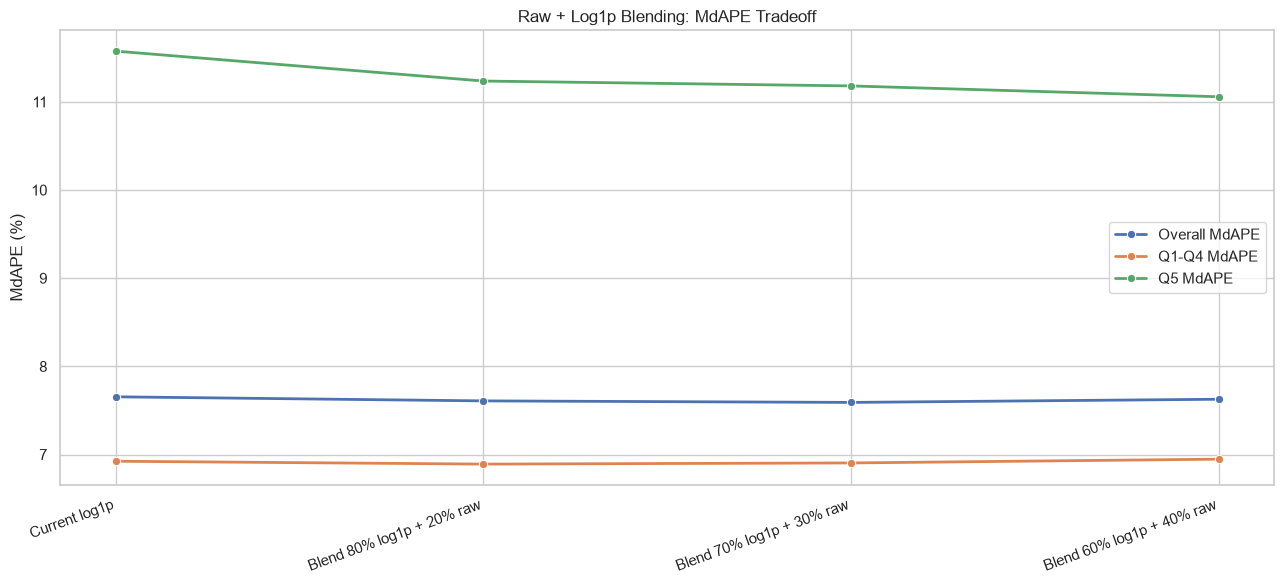

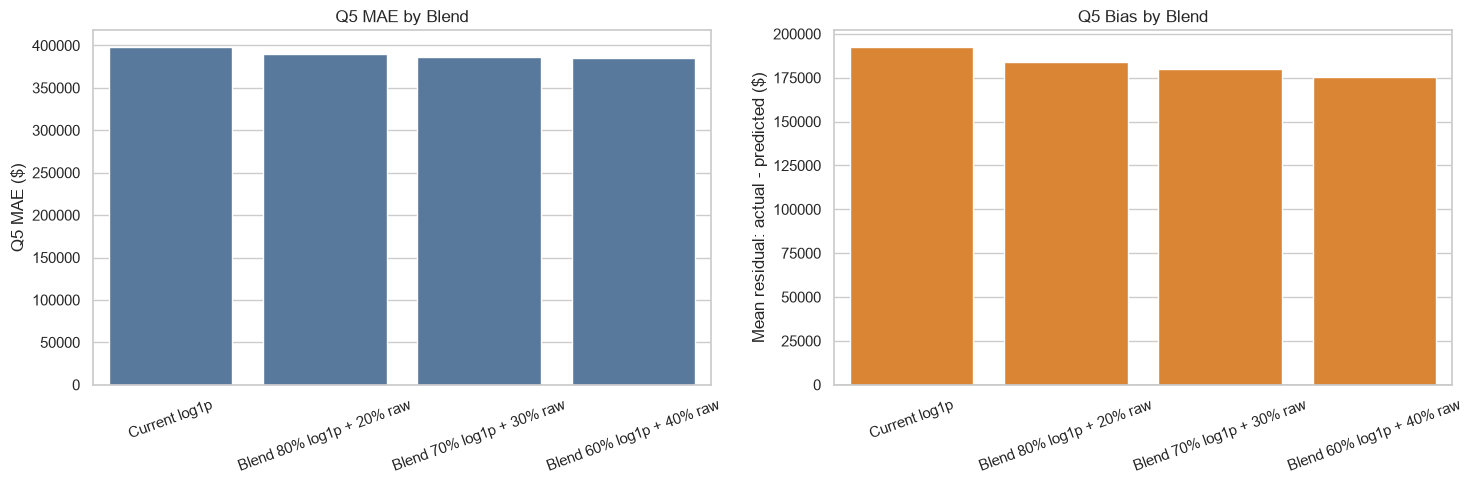

In [34]:
blend_plot_df = blend_summary_table.copy()
blend_order = [
    "Current log1p",
    "Blend 80% log1p + 20% raw",
    "Blend 70% log1p + 30% raw",
    "Blend 60% log1p + 40% raw",
]
blend_plot_df["Experiment"] = pd.Categorical(
    blend_plot_df["Experiment"],
    categories=blend_order,
    ordered=True,
)
blend_plot_df = blend_plot_df.sort_values("Experiment")

mdape_long = blend_plot_df.melt(
    id_vars="Experiment",
    value_vars=["Overall MdAPE", "Q1-Q4 MdAPE", "Q5 MdAPE"],
    var_name="Metric",
    value_name="MdAPE",
)

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=mdape_long,
    x="Experiment",
    y="MdAPE",
    hue="Metric",
    marker="o",
    linewidth=2,
)
plt.title("Raw + Log1p Blending: MdAPE Tradeoff")
plt.xlabel("")
plt.ylabel("MdAPE (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=blend_plot_df,
    x="Experiment",
    y="Q5 MAE",
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Q5 MAE by Blend")
axes[0].set_xlabel("")
axes[0].set_ylabel("Q5 MAE ($)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=blend_plot_df,
    x="Experiment",
    y="Q5 mean residual",
    color="#F58518",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Q5 Bias by Blend")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean residual: actual - predicted ($)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 10. Local Price Features + Raw/Log1p Blending Experiment

Combine the two strongest experiment ideas:
- leakage-safe local price features
- dollar-scale blending between `log1p` and raw-target XGBoost predictions

This checks whether local market context improves overall accuracy while blending reduces high-price underprediction.


In [36]:
def fit_predict_local_target_mode(train_df, eval_df, feature_cols, numeric_features, categorical_features, boolean_features, flag_features, target_transform):
    model = build_local_aggregate_xgboost_pipeline(numeric_features, categorical_features, boolean_features, flag_features)
    start_time = time.perf_counter()
    model.fit(train_df[feature_cols], transform_target_for_mode(train_df[TARGET], target_transform))
    fit_seconds = time.perf_counter() - start_time
    train_predictions = inverse_predictions_for_mode(model.predict(train_df[feature_cols]), target_transform)
    eval_predictions = inverse_predictions_for_mode(model.predict(eval_df[feature_cols]), target_transform)
    return model, train_predictions, eval_predictions, fit_seconds


def evaluate_local_blending_config(eval_name, train_raw, eval_raw, feature_config):
    train_df, eval_df, bound_info = apply_train_price_bounds(train_raw, eval_raw)
    numeric_features = available(feature_config["numeric"], train_df)
    categorical_features = available(feature_config["categorical"], train_df)
    boolean_features = available(feature_config["boolean"], train_df)
    flag_features = available(feature_config["flag"], train_df)
    local_source_features = available(["CloseDate", TARGET], train_df)
    feature_cols = list(dict.fromkeys(
        numeric_features + categorical_features + boolean_features + flag_features + local_source_features
    ))

    _, train_pred_log1p, eval_pred_log1p, fit_seconds_log1p = fit_predict_local_target_mode(
        train_df, eval_df, feature_cols, numeric_features, categorical_features, boolean_features, flag_features, "log1p"
    )
    _, train_pred_raw, eval_pred_raw, fit_seconds_raw = fit_predict_local_target_mode(
        train_df, eval_df, feature_cols, numeric_features, categorical_features, boolean_features, flag_features, "raw"
    )

    result_rows = []
    segment_frames = []
    detail_frames = []

    for experiment_name, (log1p_weight, raw_weight) in BLEND_CONFIGS.items():
        if experiment_name == "Current log1p":
            combined_name = "+ local price features"
        else:
            combined_name = f"+ local price features + {experiment_name}"

        train_predictions = log1p_weight * train_pred_log1p + raw_weight * train_pred_raw
        eval_predictions = log1p_weight * eval_pred_log1p + raw_weight * eval_pred_raw
        train_metrics = regression_metrics(train_df[TARGET], train_predictions)
        eval_metrics = regression_metrics(eval_df[TARGET], eval_predictions)
        segment_summary, detail = segment_metrics(eval_df, eval_predictions)

        q5_detail = detail[detail["ClosePrice_quintile"].astype("string").eq("Q5 highest")].copy()
        q5_metrics = regression_metrics(q5_detail[TARGET], q5_detail["predicted_ClosePrice"])
        q5_mean_residual = (q5_detail[TARGET] - q5_detail["predicted_ClosePrice"]).mean()

        result_rows.append({
            "eval_name": eval_name,
            "experiment": combined_name,
            "target_transform": "blend" if raw_weight else "log1p",
            "uses_local_aggregates": True,
            "log1p_weight": log1p_weight,
            "raw_weight": raw_weight,
            **BEST_XGB_PARAMS,
            **bound_info,
            "n_raw_features": len(feature_cols),
            "n_model_numeric_features": len(numeric_features) + len(local_aggregate_numeric_features(categorical_features)),
            "fit_seconds": fit_seconds_log1p + fit_seconds_raw,
            "train_r2": train_metrics["r2"],
            "train_mae": train_metrics["mae"],
            "eval_r2": eval_metrics["r2"],
            "eval_mae": eval_metrics["mae"],
            "eval_rmse": eval_metrics["rmse"],
            "eval_mape": eval_metrics["mape"],
            "eval_mdape": eval_metrics["mdape"],
            "train_eval_r2_gap": train_metrics["r2"] - eval_metrics["r2"],
            "q5_mae": q5_metrics["mae"],
            "q5_mape": q5_metrics["mape"],
            "q5_mdape": q5_metrics["mdape"],
            "q5_mean_residual": q5_mean_residual,
        })
        segment_summary.insert(0, "experiment", combined_name)
        segment_summary.insert(0, "eval_name", eval_name)
        detail.insert(0, "experiment", combined_name)
        detail.insert(0, "eval_name", eval_name)
        segment_frames.append(segment_summary)
        detail_frames.append(detail)

    return result_rows, segment_frames, detail_frames


local_blend_result_rows = []
local_blend_segment_frames = []
local_blend_detail_frames = []

for eval_name, (train_raw, eval_raw) in evaluation_splits.items():
    print(f"Running local + blending experiment: {eval_name}")
    rows, segments, details = evaluate_local_blending_config(eval_name, train_raw, eval_raw, FEATURE_CONFIGS["Current"])
    local_blend_result_rows.extend(rows)
    local_blend_segment_frames.extend(segments)
    local_blend_detail_frames.extend(details)

local_blend_results_df = pd.DataFrame(local_blend_result_rows).sort_values(
    ["eval_name", "eval_mdape", "eval_r2"],
    ascending=[True, True, False],
)
local_blend_segment_results_df = pd.concat(local_blend_segment_frames, ignore_index=True)
local_blend_prediction_detail_df = pd.concat(local_blend_detail_frames, ignore_index=True)

local_blend_results_df.to_csv(OUTPUT_DIR / "local_price_feature_blending_experiment_results.csv", index=False)
local_blend_segment_results_df.to_csv(OUTPUT_DIR / "local_price_feature_blending_experiment_segment_results.csv", index=False)
local_blend_prediction_detail_df.to_csv(OUTPUT_DIR / "local_price_feature_blending_experiment_predictions.csv", index=False)

display(local_blend_results_df.round(4))


Running local + blending experiment: validation_2026-05
Running local + blending experiment: final_test_2026-06


,eval_name,experiment,target_transform,uses_local_aggregates,log1p_weight,raw_weight,max_depth,learning_rate,n_estimators,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_filter,train_rows_after_filter,eval_rows_before_filter,eval_rows_after_filter,n_raw_features,n_model_numeric_features,fit_seconds,train_r2,train_mae,eval_r2,eval_mae,eval_rmse,eval_mape,eval_mdape,train_eval_r2_gap,q5_mae,q5_mape,q5_mdape,q5_mean_residual
7,final_test_2026-06,+ local price features + Blend 60% log1p + 40%...,blend,True,0.6,0.4,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,56,25,36.1613,0.9775,81519.2419,0.9178,140201.0457,274472.0281,10.3697,7.1743,0.0597,371995.5172,13.0825,10.5263,173471.5031
6,final_test_2026-06,+ local price features + Blend 70% log1p + 30%...,blend,True,0.7,0.3,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,56,25,36.1613,0.9762,82283.5194,0.9172,140552.3051,275347.8367,10.3674,7.1919,0.0589,373697.6442,13.1254,10.5390,178702.2385
5,final_test_2026-06,+ local price features + Blend 80% log1p + 20%...,blend,True,0.8,0.2,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,56,25,36.1613,0.9747,83167.6448,0.9164,141164.8373,276813.9664,10.3853,7.2035,0.0583,376011.1245,13.1907,10.5847,183932.8576
4,final_test_2026-06,+ local price features,log1p,True,1.0,0.0,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,12858,12538,56,25,36.1613,0.9712,85317.7956,0.9135,143230.3935,281476.6219,10.4809,7.3098,0.0577,382956.3564,13.4042,11.0443,194394.2235
3,validation_2026-05,+ local price features + Blend 60% log1p + 40%...,blend,True,0.6,0.4,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,56,25,33.8757,0.9777,81195.6974,0.9128,142461.1108,278554.5416,10.5113,7.2727,0.0649,379154.2326,13.3731,10.8658,172926.9304
1,validation_2026-05,+ local price features + Blend 80% log1p + 20%...,blend,True,0.8,0.2,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,56,25,33.8757,0.9749,82865.2820,0.9111,143408.0886,281188.9457,10.5237,7.3058,0.0638,383860.9436,13.5293,11.0281,181321.1985
2,validation_2026-05,+ local price features + Blend 70% log1p + 30%...,blend,True,0.7,0.3,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,56,25,33.8757,0.9764,81967.9145,0.9122,142808.1376,279560.6431,10.5076,7.3159,0.0642,381224.7698,13.4408,11.0565,177124.1255
0,validation_2026-05,+ local price features,log1p,True,1.0,0.0,9,0.1,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,12014,11719,56,25,33.8757,0.9715,85034.5104,0.9079,145530.5962,286265.6830,10.6256,7.3814,0.0636,391591.6631,13.7917,11.2041,189715.4885


## 10.1 Local + Blending Summary Table


In [37]:
local_blend_summary_table = final_experiment_summary_table(local_blend_results_df, local_blend_prediction_detail_df)
local_blend_summary_table.to_csv(OUTPUT_DIR / "local_price_feature_blending_experiment_decision_summary.csv", index=False)
display(local_blend_summary_table.round({
    "Overall MdAPE": 4,
    "Q1-Q4 MdAPE": 4,
    "Q5 MdAPE": 4,
    "Q5 MAE": 2,
    "Q5 mean residual": 2,
}))


,Experiment,Overall MdAPE,Q1-Q4 MdAPE,Q5 MdAPE,Q5 MAE,Q5 Bias,Q5 mean residual
0,+ local price features + Blend 60% log1p + 40%...,7.1743,6.5882,10.5263,371995.52,under,173471.50
1,+ local price features + Blend 70% log1p + 30%...,7.1919,6.6254,10.5390,373697.64,under,178702.24
2,+ local price features + Blend 80% log1p + 20%...,7.2035,6.6107,10.5847,376011.12,under,183932.86
3,+ local price features,7.3098,6.6462,11.0443,382956.36,under,194394.22


## 10.2 Local + Blending Visual Comparison

Use these plots to compare whether adding raw-target signal on top of local price features improves Q5/luxury performance without hurting the overall MdAPE too much.


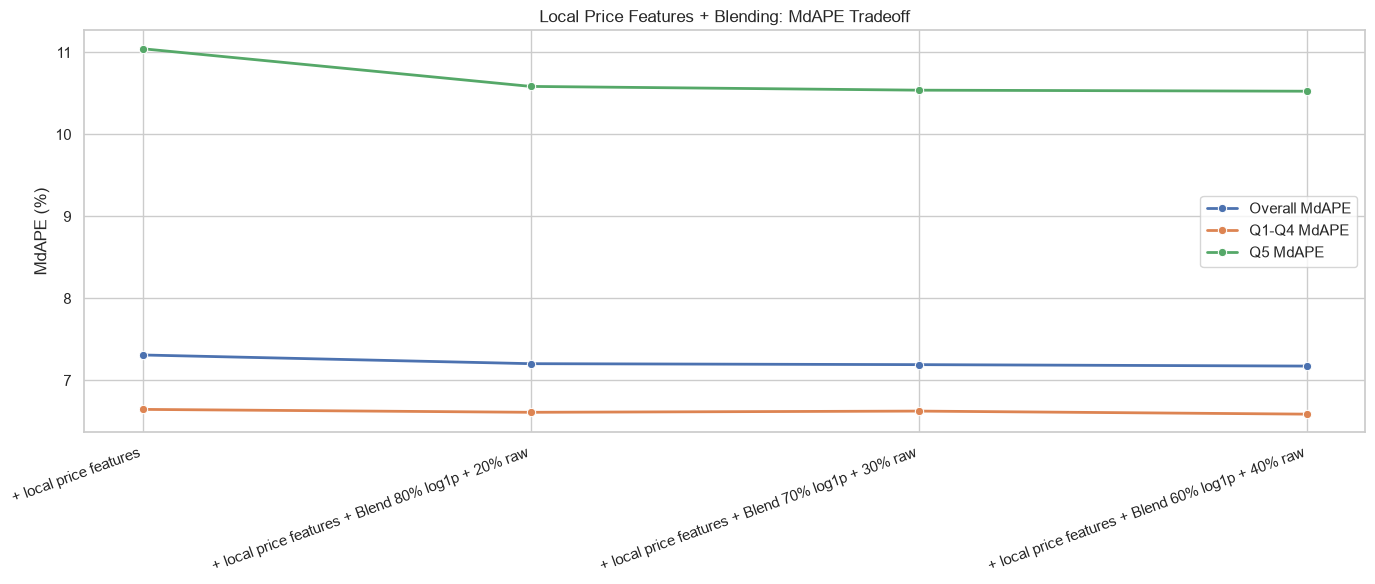

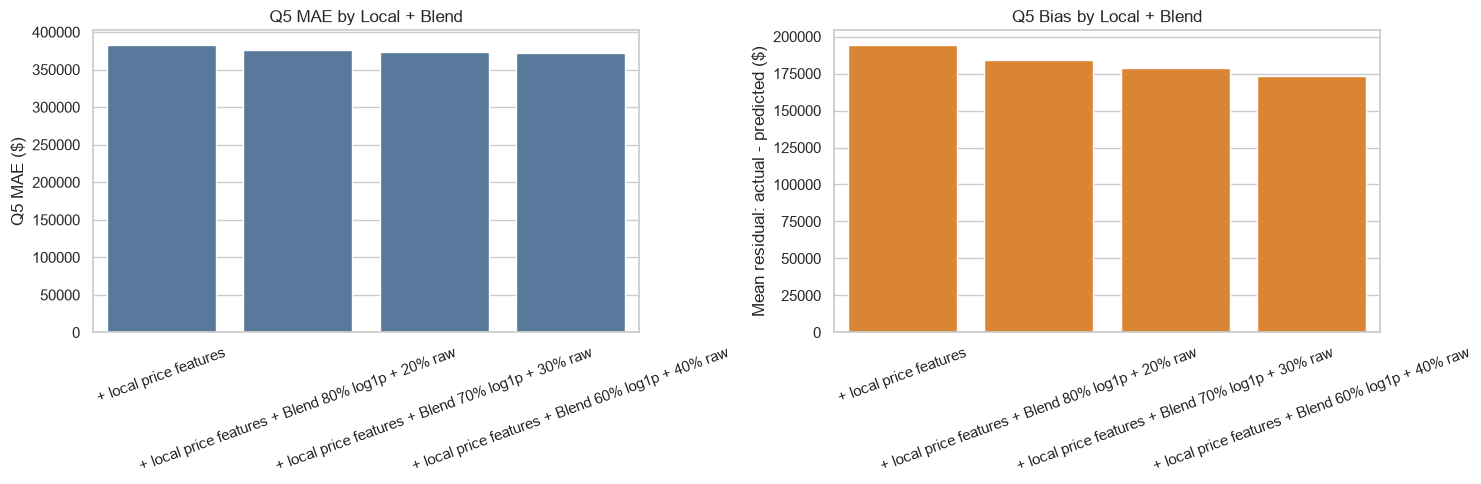

In [38]:
local_blend_plot_df = local_blend_summary_table.copy()
local_blend_order = [
    "+ local price features",
    "+ local price features + Blend 80% log1p + 20% raw",
    "+ local price features + Blend 70% log1p + 30% raw",
    "+ local price features + Blend 60% log1p + 40% raw",
]
local_blend_plot_df["Experiment"] = pd.Categorical(
    local_blend_plot_df["Experiment"],
    categories=local_blend_order,
    ordered=True,
)
local_blend_plot_df = local_blend_plot_df.sort_values("Experiment")

local_blend_mdape_long = local_blend_plot_df.melt(
    id_vars="Experiment",
    value_vars=["Overall MdAPE", "Q1-Q4 MdAPE", "Q5 MdAPE"],
    var_name="Metric",
    value_name="MdAPE",
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=local_blend_mdape_long,
    x="Experiment",
    y="MdAPE",
    hue="Metric",
    marker="o",
    linewidth=2,
)
plt.title("Local Price Features + Blending: MdAPE Tradeoff")
plt.xlabel("")
plt.ylabel("MdAPE (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=local_blend_plot_df,
    x="Experiment",
    y="Q5 MAE",
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Q5 MAE by Local + Blend")
axes[0].set_xlabel("")
axes[0].set_ylabel("Q5 MAE ($)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=local_blend_plot_df,
    x="Experiment",
    y="Q5 mean residual",
    color="#F58518",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Q5 Bias by Local + Blend")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean residual: actual - predicted ($)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 11. Unified Experiment Decision Table

Use this table to compare all experimental branches with the same decision columns.


In [39]:
def relabel_experiment_rows(summary_df, label_map=None, source=None):
    result = summary_df.copy()
    if label_map:
        result["Experiment"] = result["Experiment"].replace(label_map)
    if source is not None:
        result.insert(0, "Source", source)
    return result


summary_tables = []

if "log_size_summary_table" in globals():
    summary_tables.append(relabel_experiment_rows(
        log_size_summary_table,
        {
            "Current": "Current log1p",
            "Current + log size features": "+ log size features",
        },
        "log_size",
    ))

if "sample_weighting_summary_table" in globals():
    weighting_rows = sample_weighting_summary_table[
        ~sample_weighting_summary_table["Experiment"].eq("unweighted")
    ].copy()
    summary_tables.append(relabel_experiment_rows(
        weighting_rows,
        {
            "top20_weight_1.5": "+ weighting top20 x1.5",
            "top20_weight_2.0": "+ weighting top20 x2.0",
        },
        "sample_weighting",
    ))

if "local_aggregate_summary_table" in globals():
    local_rows = local_aggregate_summary_table[
        ~local_aggregate_summary_table["Experiment"].eq("Current log1p")
    ].copy()
    summary_tables.append(relabel_experiment_rows(local_rows, source="local_price_features"))

if "blend_summary_table" in globals():
    blend_rows = blend_summary_table[
        ~blend_summary_table["Experiment"].eq("Current log1p")
    ].copy()
    summary_tables.append(relabel_experiment_rows(blend_rows, source="blend"))

if "local_blend_summary_table" in globals():
    local_blend_rows = local_blend_summary_table[
        ~local_blend_summary_table["Experiment"].eq("+ local price features")
    ].copy()
    summary_tables.append(relabel_experiment_rows(local_blend_rows, source="local_price_features_blend"))

unified_experiment_summary_table = pd.concat(summary_tables, ignore_index=True)
unified_experiment_summary_table = unified_experiment_summary_table.sort_values(
    ["Overall MdAPE", "Q5 MdAPE"],
    ascending=[True, True],
).reset_index(drop=True)

unified_experiment_summary_table.to_csv(OUTPUT_DIR / "unified_experiment_decision_summary.csv", index=False)
display(unified_experiment_summary_table.round({
    "Overall MdAPE": 4,
    "Q1-Q4 MdAPE": 4,
    "Q5 MdAPE": 4,
    "Q5 MAE": 2,
    "Q5 mean residual": 2,
}))


,Source,Experiment,Overall MdAPE,Q1-Q4 MdAPE,Q5 MdAPE,Q5 MAE,Q5 Bias,Q5 mean residual
0,local_price_features_blend,+ local price features + Blend 60% log1p + 40%...,7.1743,6.5882,10.5263,371995.52,under,173471.50
1,local_price_features_blend,+ local price features + Blend 70% log1p + 30%...,7.1919,6.6254,10.5390,373697.64,under,178702.24
2,local_price_features_blend,+ local price features + Blend 80% log1p + 20%...,7.2035,6.6107,10.5847,376011.12,under,183932.86
3,local_price_features,+ local price features,7.3098,6.6462,11.0443,382956.36,under,194394.22
4,blend,Blend 70% log1p + 30% raw,7.5908,6.9044,11.1803,386874.25,under,179792.53
5,blend,Blend 80% log1p + 20% raw,7.6082,6.8913,11.2357,389759.96,under,183966.95
6,blend,Blend 60% log1p + 40% raw,7.6269,6.9473,11.0575,384865.25,under,175617.99
7,log_size,Current log1p,7.6545,6.9239,11.5751,397758.48,under,192315.92
8,log_size,+ log size features,7.6545,6.9239,11.5751,397758.48,under,192315.92
9,sample_weighting,+ weighting top20 x1.5,7.7512,7.0657,11.2326,394973.86,under,181036.71


## 12. Quick Decision Notes

Log size feature experiment:
- Adding `LogLivingArea` and `LogLotSizeSquareFeet` produced no measurable change.
- Overall MdAPE stayed `7.6545%`, Q5 MdAPE stayed `11.5751%`, Q5 MAE stayed about `$397.8K`, and Q5 bias stayed `under`.
- Decision: do not add these log size features to the main model for now.

Sample weighting experiment:
- Weighting the top 20% training prices improved Q5 errors but hurt overall and Q1-Q4 MdAPE.
- `top20_weight_1.5` reduced Q5 MdAPE from `11.5751%` to `11.2326%` and Q5 mean residual from about `$192K` to `$181K`, but overall MdAPE worsened from `7.6545%` to `7.7512%`.
- `top20_weight_2.0` reduced Q5 MAE slightly more, but overall MdAPE worsened further to `7.7941%`.
- Decision: useful diagnostic, but not the best final choice because it sacrifices too much broad accuracy.

Local price feature experiment:
- Local price features improved overall MdAPE and Q5 error in the first standalone test.
- Decision: strong candidate for the main model, but check the combined local + blending table before finalizing.

Raw + log1p blending experiment:
- Blending was the best experiment overall.
- `70% log1p + 30% raw` had the best overall MdAPE at `7.5908%`, improved Q5 MdAPE to `11.1803%`, reduced Q5 MAE to about `$386.9K`, and reduced Q5 mean residual to about `$180K`.
- `60% log1p + 40% raw` had the best Q5 metrics, with Q5 MdAPE `11.0575%`, Q5 MAE about `$384.9K`, and Q5 mean residual about `$176K`, but its overall MdAPE was slightly worse than the 70/30 blend.
- Decision: if selecting by overall MdAPE with better luxury performance, use `70% log1p + 30% raw`. If prioritizing Q5/luxury correction more strongly, consider `60% log1p + 40% raw`.

Local price features + raw/log1p blending experiment:
- This final experiment tests whether the two strongest ideas work better together than separately.
- Decision rule: prefer the combined option only if it improves or preserves overall MdAPE while reducing Q5 MdAPE, Q5 MAE, and Q5 mean residual compared with `+ local price features` alone.


## 13. Final Model vs Baseline Price Quintile Plots

Compare the current baseline XGBoost log1p model against the final candidate, `local price features + Blend 60% log1p + 40% raw`, by price quintile on the final test month.


MdAPE by price quintile


Price quintile,Overall,Q1 lowest,Q2,Q3,Q4,Q5 highest
Model,,,,,,
Baseline: Current log1p,7.6545,6.8499,5.6768,6.8794,8.7205,11.5751
Final: local + 60/40 blend,7.1743,6.5748,5.2588,6.6864,8.0136,10.5263


MAE by price quintile


Price quintile,Overall,Q1 lowest,Q2,Q3,Q4,Q5 highest
Model,,,,,,
Baseline: Current log1p,148075.10,47141.81,57459.31,90056.82,149221.14,397758.48
Final: local + 60/40 blend,140201.05,45992.37,55115.94,88374.73,140647.83,371995.52


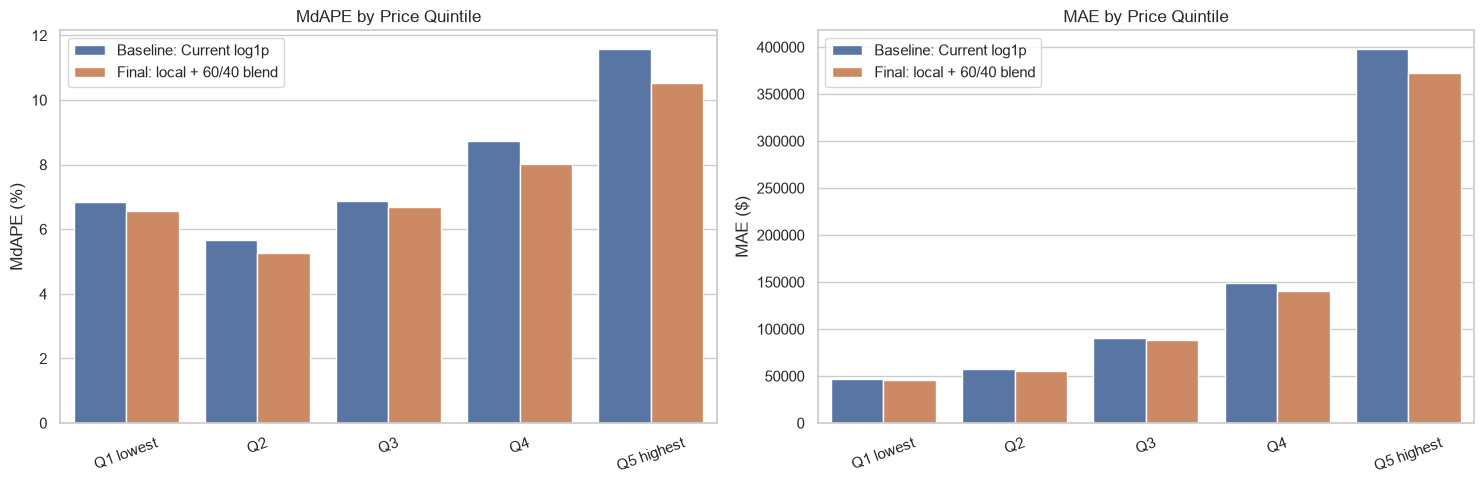

In [43]:
BASELINE_EXPERIMENT_NAME = "Current log1p"
FINAL_EXPERIMENT_NAME = "+ local price features + Blend 60% log1p + 40% raw"
FINAL_TEST_EVAL_NAME = "final_test_2026-06"
PRICE_QUINTILE_ORDER = ["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"]

baseline_prediction_path = OUTPUT_DIR / "raw_log1p_blending_experiment_predictions.csv"
final_prediction_path = OUTPUT_DIR / "local_price_feature_blending_experiment_predictions.csv"

if "blend_prediction_detail_df" in globals():
    baseline_detail = blend_prediction_detail_df.copy()
else:
    baseline_detail = pd.read_csv(baseline_prediction_path, low_memory=False)

if "local_blend_prediction_detail_df" in globals():
    final_detail = local_blend_prediction_detail_df.copy()
else:
    final_detail = pd.read_csv(final_prediction_path, low_memory=False)

baseline_plot_detail = baseline_detail[
    baseline_detail["eval_name"].eq(FINAL_TEST_EVAL_NAME)
    & baseline_detail["experiment"].eq(BASELINE_EXPERIMENT_NAME)
].copy()
final_plot_detail = final_detail[
    final_detail["eval_name"].eq(FINAL_TEST_EVAL_NAME)
    & final_detail["experiment"].eq(FINAL_EXPERIMENT_NAME)
].copy()

baseline_plot_detail["model_version"] = "Baseline: Current log1p"
final_plot_detail["model_version"] = "Final: local + 60/40 blend"
price_quintile_plot_detail = pd.concat([baseline_plot_detail, final_plot_detail], ignore_index=True)

for col in [TARGET, "predicted_ClosePrice", "absolute_error", "absolute_percentage_error"]:
    price_quintile_plot_detail[col] = pd.to_numeric(price_quintile_plot_detail[col], errors="coerce")

price_quintile_metric_plot_df = (
    price_quintile_plot_detail
    .groupby(["model_version", "ClosePrice_quintile"], observed=True)
    .agg(
        count=(TARGET, "size"),
        mdape=("absolute_percentage_error", "median"),
        mae=("absolute_error", "mean"),
    )
    .reset_index()
)
price_quintile_metric_plot_df["ClosePrice_quintile"] = pd.Categorical(
    price_quintile_metric_plot_df["ClosePrice_quintile"],
    categories=PRICE_QUINTILE_ORDER,
    ordered=True,
)
price_quintile_metric_plot_df = price_quintile_metric_plot_df.sort_values(["ClosePrice_quintile", "model_version"])

overall_metric_plot_df = (
    price_quintile_plot_detail
    .groupby("model_version", observed=True)
    .agg(
        mdape=("absolute_percentage_error", "median"),
        mae=("absolute_error", "mean"),
    )
)

price_quintile_mdape_table = (
    price_quintile_metric_plot_df
    .pivot(index="model_version", columns="ClosePrice_quintile", values="mdape")
    .reindex(columns=PRICE_QUINTILE_ORDER)
)
price_quintile_mdape_table.insert(0, "Overall", overall_metric_plot_df["mdape"])
price_quintile_mdape_table = price_quintile_mdape_table.rename_axis(index="Model", columns="Price quintile")

price_quintile_mae_table = (
    price_quintile_metric_plot_df
    .pivot(index="model_version", columns="ClosePrice_quintile", values="mae")
    .reindex(columns=PRICE_QUINTILE_ORDER)
)
price_quintile_mae_table.insert(0, "Overall", overall_metric_plot_df["mae"])
price_quintile_mae_table = price_quintile_mae_table.rename_axis(index="Model", columns="Price quintile")

print("MdAPE by price quintile")
display(price_quintile_mdape_table.round(4))
print("MAE by price quintile")
display(price_quintile_mae_table.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=price_quintile_metric_plot_df,
    x="ClosePrice_quintile",
    y="mdape",
    hue="model_version",
    order=PRICE_QUINTILE_ORDER,
    ax=axes[0],
)
axes[0].set_title("MdAPE by Price Quintile")
axes[0].set_xlabel("")
axes[0].set_ylabel("MdAPE (%)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="")

sns.barplot(
    data=price_quintile_metric_plot_df,
    x="ClosePrice_quintile",
    y="mae",
    hue="model_version",
    order=PRICE_QUINTILE_ORDER,
    ax=axes[1],
)
axes[1].set_title("MAE by Price Quintile")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE ($)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="")

plt.tight_layout()
plt.show()
